<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/Visualization_of_Magnon_Mediated_Quantum_Entanglement_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

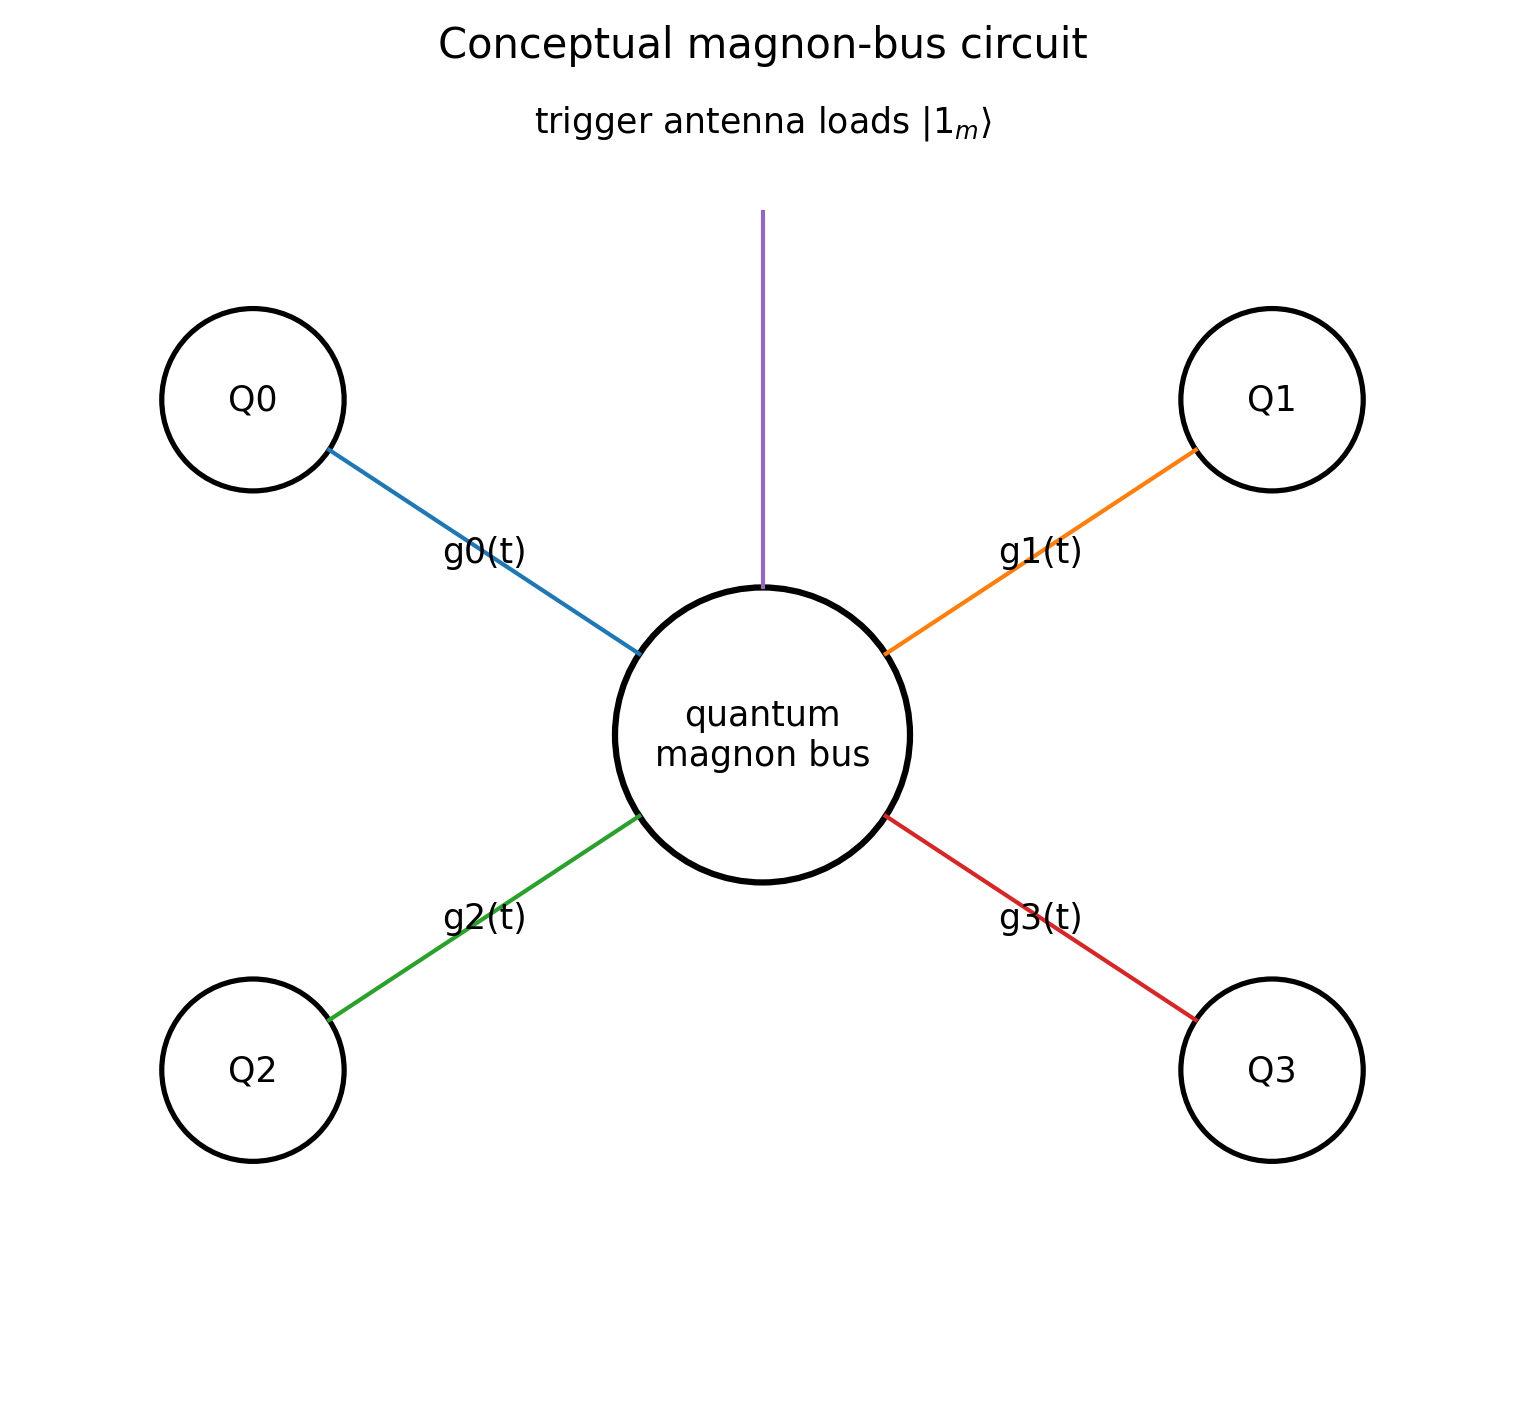

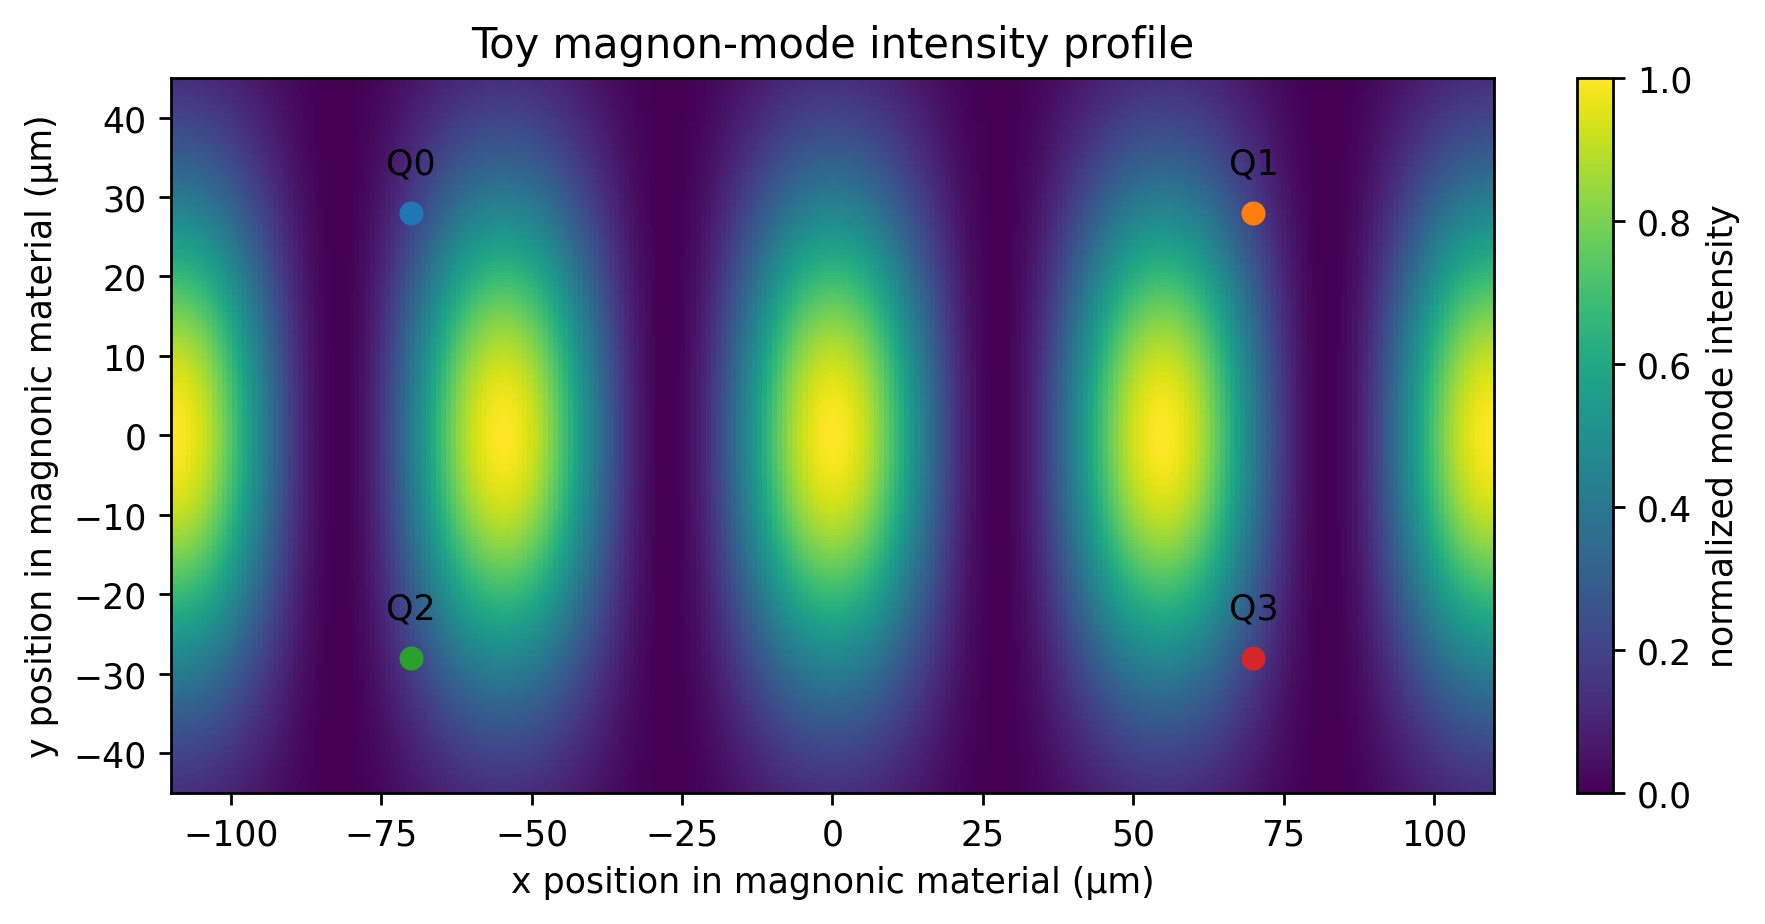

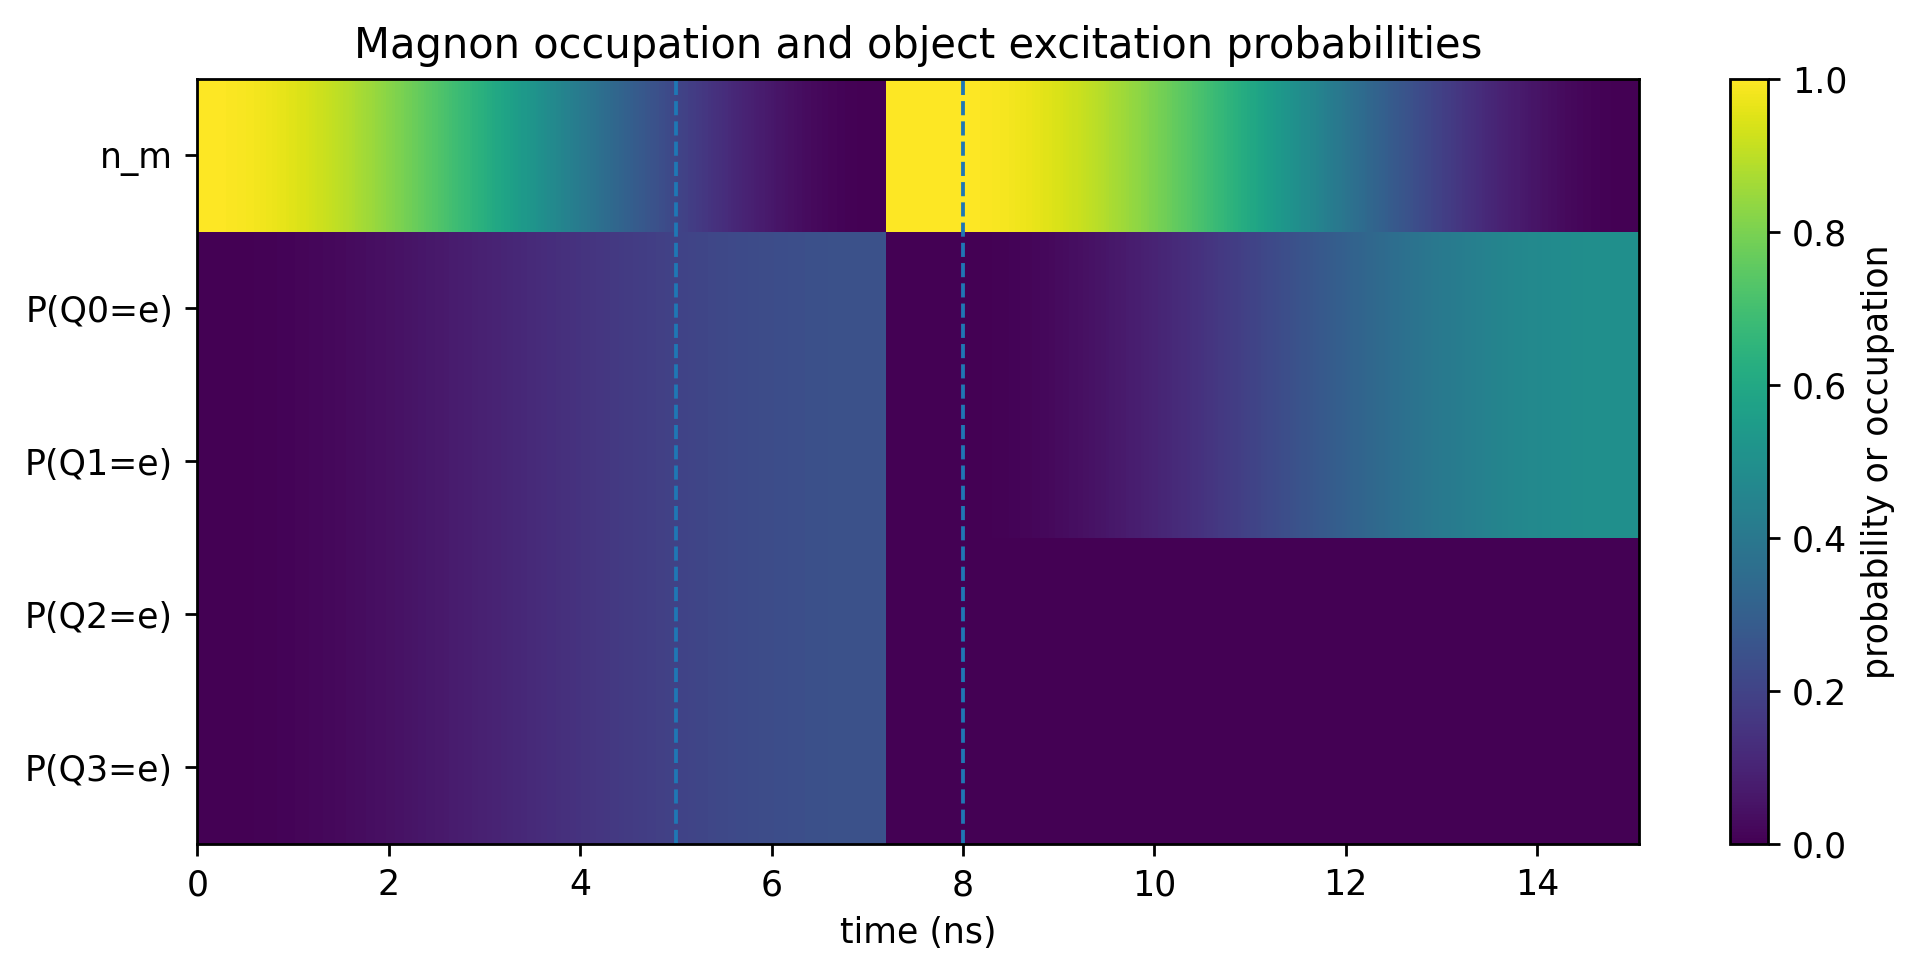

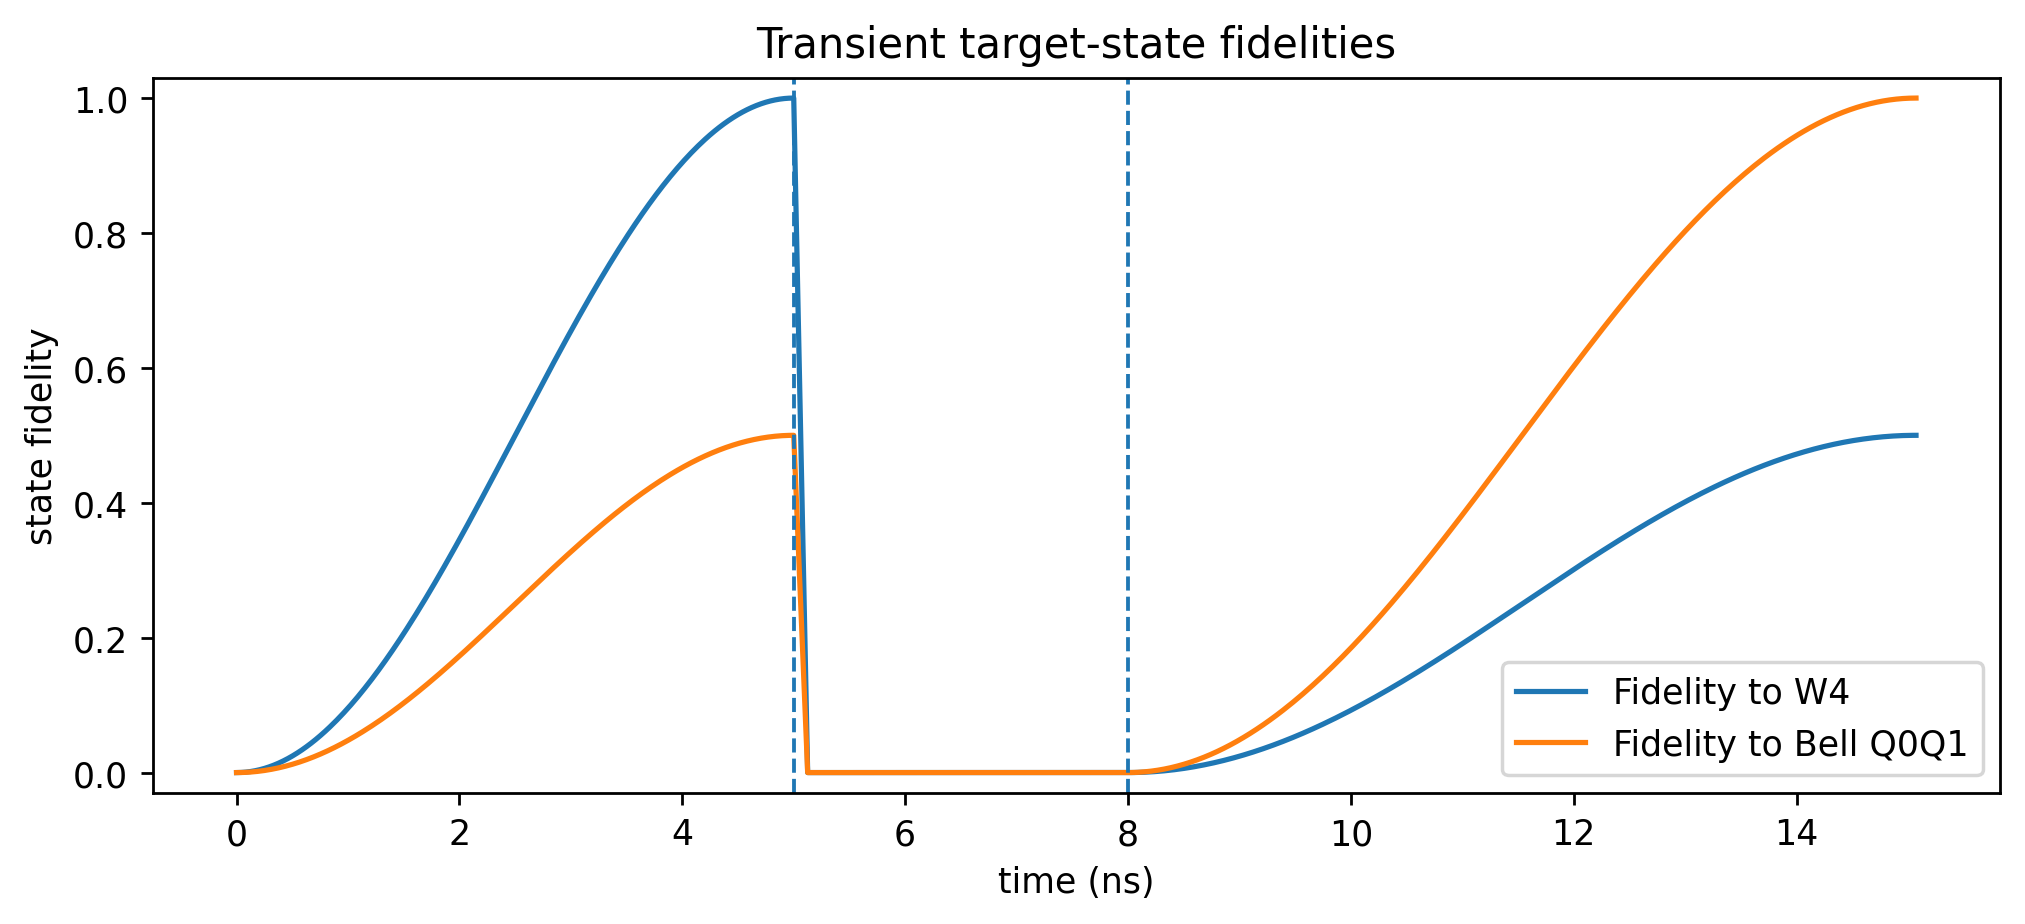

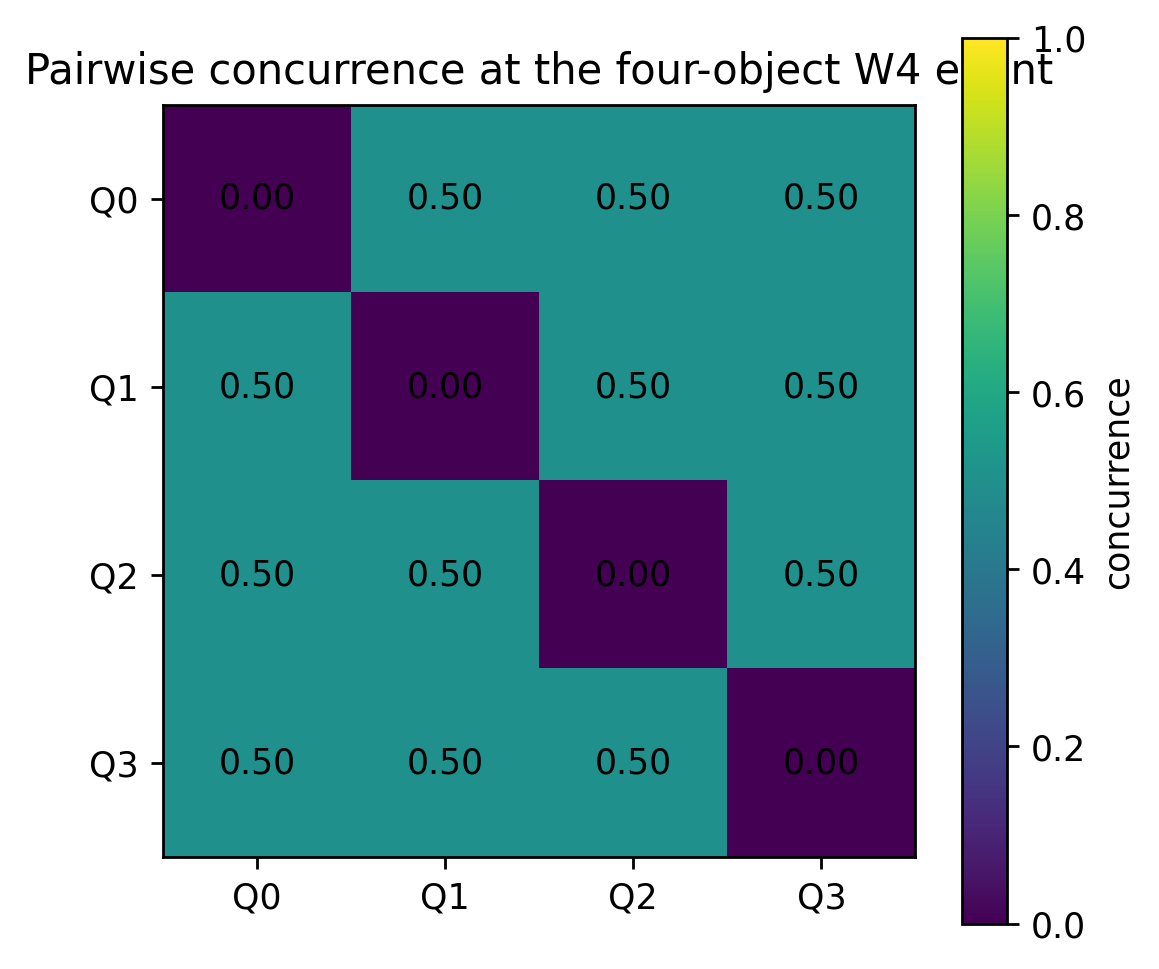

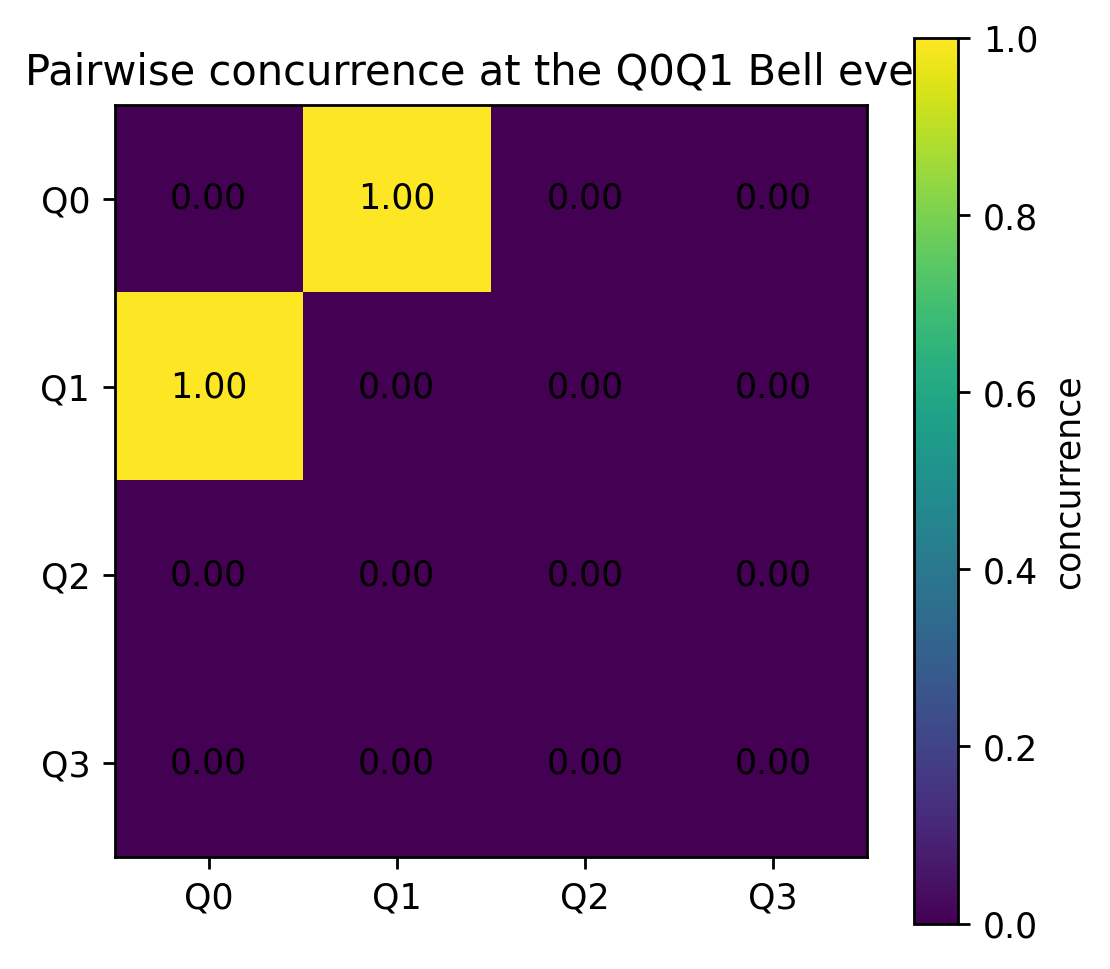

Stage 1 W4 event time: 5.000 ns
Stage 2 Bell event time: 15.071 ns
W4 fidelity at stage 1 event: 1.000000
Bell fidelity at stage 2 event: 1.000000
Pairwise concurrence at W4 event:
[[0.  0.5 0.5 0.5]
 [0.5 0.  0.5 0.5]
 [0.5 0.5 0.  0.5]
 [0.5 0.5 0.5 0. ]]
Pairwise concurrence at Bell event:
[[0. 1. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


In [5]:
"""Simulate transient magnon-mediated entanglement among four objects.

The model treats one quantum magnon mode as a shared bus coupled to four
ideal two-level quantum objects. The first trigger distributes one magnon
into a four-object W state. The second trigger reloads the bus and creates
a Bell-like state between a selected pair.
"""

from dataclasses import dataclass
from typing import Final, Sequence

import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams


# ---------------------------------------------------------------------------
# Control knobs.
# ---------------------------------------------------------------------------
rcParams["figure.dpi"] = 250
rcParams["mathtext.fontset"] = "dejavusans"

NUM_OBJECTS: Final[int] = 4
N_MAGNON_LEVELS: Final[int] = 2

# Coupling g / 2π = 25 MHz. Since 1 MHz = 0.001 cycles/ns,
# g = 2π × 0.025 rad/ns.
COUPLING_G_RAD_PER_NS: Final[float] = 2.0 * np.pi * 0.025

NUM_TIME_SAMPLES_STAGE: Final[int] = 240
NUM_TIME_SAMPLES_RESET: Final[int] = 24
RESET_GAP_NS: Final[float] = 3.0

PAIR_FOR_STAGE_2: Final[tuple[int, int]] = (0, 1)
DIMS: Final[tuple[int, ...]] = (N_MAGNON_LEVELS,) + (2,) * NUM_OBJECTS

MODE_LENGTH_UM: Final[float] = 220.0
MODE_WIDTH_UM: Final[float] = 90.0
MODE_GRID_POINTS: Final[int] = 260
MODE_WAVELENGTH_UM: Final[float] = 110.0
MODE_TRANSVERSE_WIDTH_UM: Final[float] = 32.0

OBJECT_POSITIONS_UM: Final[tuple[tuple[float, float], ...]] = (
    (-70.0, 28.0),
    (70.0, 28.0),
    (-70.0, -28.0),
    (70.0, -28.0),
)


@dataclass(frozen=True)
class ProtocolResult:
    """Stores state-vector samples and event times."""

    times_ns: np.ndarray
    states: np.ndarray
    stage_1_end_ns: float
    stage_2_start_ns: float
    stage_2_end_ns: float


@dataclass(frozen=True)
class MetricResult:
    """Stores computed magnonic and entanglement observables."""

    magnon_number: np.ndarray
    object_probabilities: np.ndarray
    w4_fidelity: np.ndarray
    bell_fidelity: np.ndarray
    pair_concurrence: np.ndarray


def basis(dim: int, index: int) -> np.ndarray:
    """Return a computational basis vector.

    Args:
        dim: Hilbert-space dimension.
        index: Basis-state index.

    Returns:
        Complex basis vector with unit amplitude at the selected index.
    """
    vector = np.zeros(dim, dtype=complex)
    vector[index] = 1.0
    return vector


def tensor_product(vectors: Sequence[np.ndarray]) -> np.ndarray:
    """Return the Kronecker product of a sequence of vectors.

    Args:
        vectors: Ordered local state vectors.

    Returns:
        Composite state vector.
    """
    state = np.array([1.0 + 0.0j])
    for vector in vectors:
        state = np.kron(state, vector)
    return state


def annihilation_operator(num_levels: int) -> np.ndarray:
    """Return a truncated bosonic annihilation operator.

    Args:
        num_levels: Number of Fock states retained.

    Returns:
        Matrix representation of the annihilation operator.
    """
    operator = np.zeros((num_levels, num_levels), dtype=complex)
    for level in range(1, num_levels):
        operator[level - 1, level] = np.sqrt(level)
    return operator


def tensor_operator(
    local_operator: np.ndarray,
    target: int,
    dims: Sequence[int],
) -> np.ndarray:
    """Embed a local operator into the full tensor-product space.

    Args:
        local_operator: Operator acting on one subsystem.
        target: Target subsystem index. The magnon bus has index zero.
        dims: Local dimensions for each subsystem.

    Returns:
        Full Hilbert-space operator.
    """
    operator = np.array([[1.0 + 0.0j]])
    for index, dim in enumerate(dims):
        factor = local_operator if index == target else np.eye(dim)
        operator = np.kron(operator, factor)
    return operator


def build_hamiltonian(
    couplings_rad_per_ns: Sequence[float],
    detunings_rad_per_ns: Sequence[float] | None = None,
    magnon_detuning_rad_per_ns: float = 0.0,
) -> np.ndarray:
    """Build a rotating-frame magnon-bus Hamiltonian.

    Args:
        couplings_rad_per_ns: Coupling strengths for the four objects.
        detunings_rad_per_ns: Object detunings in the rotating frame.
        magnon_detuning_rad_per_ns: Magnon-mode detuning.

    Returns:
        Hermitian Hamiltonian in angular-frequency units.
    """
    if len(couplings_rad_per_ns) != NUM_OBJECTS:
        raise ValueError("One coupling value is required for each object.")

    if detunings_rad_per_ns is None:
        detunings = np.zeros(NUM_OBJECTS)
    else:
        detunings = np.asarray(detunings_rad_per_ns, dtype=float)

    if detunings.shape != (NUM_OBJECTS,):
        raise ValueError("One detuning value is required for each object.")

    magnon_lower = tensor_operator(
        annihilation_operator(N_MAGNON_LEVELS),
        target=0,
        dims=DIMS,
    )
    magnon_raise = magnon_lower.conj().T
    magnon_number = magnon_raise @ magnon_lower

    sigma_plus = np.array([[0.0, 0.0], [1.0, 0.0]], dtype=complex)
    sigma_minus = sigma_plus.conj().T
    excited_projector = sigma_plus @ sigma_minus

    hamiltonian = magnon_detuning_rad_per_ns * magnon_number

    for object_index, coupling in enumerate(couplings_rad_per_ns, start=1):
        object_raise = tensor_operator(sigma_plus, object_index, DIMS)
        object_lower = tensor_operator(sigma_minus, object_index, DIMS)
        object_excited = tensor_operator(excited_projector, object_index, DIMS)

        hamiltonian = hamiltonian + detunings[object_index - 1] * object_excited
        hamiltonian = hamiltonian + coupling * (
            magnon_lower @ object_raise + magnon_raise @ object_lower
        )

    return hamiltonian


def evolve_state(
    hamiltonian: np.ndarray,
    initial_state: np.ndarray,
    times_ns: np.ndarray,
) -> np.ndarray:
    """Evolve a pure state under a time-independent Hamiltonian.

    Args:
        hamiltonian: Hermitian Hamiltonian in rad/ns.
        initial_state: Initial state vector.
        times_ns: Local evolution times.

    Returns:
        Array of state vectors sampled at the requested times.
    """
    eigenvalues, eigenvectors = np.linalg.eigh(hamiltonian)
    coefficients = eigenvectors.conj().T @ initial_state
    phases = np.exp(-1j * np.outer(times_ns, eigenvalues))
    states = (phases * coefficients) @ eigenvectors.T
    return states


def make_initial_magnon_state() -> np.ndarray:
    """Return |1_m, gggg>, meaning one bus magnon and all objects in ground."""
    local_states = [basis(N_MAGNON_LEVELS, 1)]
    local_states.extend(basis(2, 0) for _ in range(NUM_OBJECTS))
    return tensor_product(local_states)


def make_w4_state() -> np.ndarray:
    """Return |0_m> tensor the four-object one-excitation W state."""
    total_dim = int(np.prod(DIMS))
    state = np.zeros(total_dim, dtype=complex)

    for excited_object in range(NUM_OBJECTS):
        local_states = [basis(N_MAGNON_LEVELS, 0)]
        for object_index in range(NUM_OBJECTS):
            if object_index == excited_object:
                local_state = basis(2, 1)
            else:
                local_state = basis(2, 0)
            local_states.append(local_state)
        state = state + tensor_product(local_states)

    return state / np.linalg.norm(state)


def make_bell_pair_state(pair: tuple[int, int]) -> np.ndarray:
    """Return |0_m> tensor a Bell-like single-excitation state for a pair.

    Args:
        pair: Pair of object indices that should share the Bell-like state.

    Returns:
        Composite target state.
    """
    total_dim = int(np.prod(DIMS))
    state = np.zeros(total_dim, dtype=complex)

    for excited_object in pair:
        local_states = [basis(N_MAGNON_LEVELS, 0)]
        for object_index in range(NUM_OBJECTS):
            if object_index == excited_object:
                local_state = basis(2, 1)
            else:
                local_state = basis(2, 0)
            local_states.append(local_state)
        state = state + tensor_product(local_states)

    return state / np.linalg.norm(state)


def partial_trace(
    density_matrix: np.ndarray,
    dims: Sequence[int],
    keep: Sequence[int],
) -> np.ndarray:
    """Trace out all subsystems except the requested subsystem indices.

    Args:
        density_matrix: Full density matrix.
        dims: Local subsystem dimensions.
        keep: Subsystem indices retained in the reduced density matrix.

    Returns:
        Reduced density matrix.
    """
    kept_indices = sorted(keep)
    traced_indices = [
        index for index in range(len(dims)) if index not in kept_indices
    ]

    tensor = density_matrix.reshape(*dims, *dims)
    current_dims = list(dims)

    for subsystem in reversed(traced_indices):
        tensor = np.trace(
            tensor,
            axis1=subsystem,
            axis2=subsystem + len(current_dims),
        )
        current_dims.pop(subsystem)

    final_dim = int(np.prod([dims[index] for index in kept_indices]))
    return tensor.reshape(final_dim, final_dim)


def concurrence(two_qubit_density_matrix: np.ndarray) -> float:
    """Compute Wootters concurrence for a two-qubit density matrix.

    Args:
        two_qubit_density_matrix: Four-by-four reduced density matrix.

    Returns:
        Pairwise concurrence bounded between zero and one.
    """
    sigma_y = np.array([[0.0, -1j], [1j, 0.0]], dtype=complex)
    spin_flip = np.kron(sigma_y, sigma_y)

    rho = two_qubit_density_matrix
    matrix = rho @ spin_flip @ rho.conj() @ spin_flip
    eigenvalues = np.linalg.eigvals(matrix)
    roots = np.sqrt(np.clip(np.real(eigenvalues), 0.0, None))
    roots = np.sort(roots)[::-1]

    return float(max(0.0, roots[0] - np.sum(roots[1:])))


def run_two_trigger_protocol() -> ProtocolResult:
    """Run the W4 trigger followed by a selected-pair Bell trigger.

    Returns:
        ProtocolResult containing sampled state vectors and event times.
    """
    coupling = COUPLING_G_RAD_PER_NS

    stage_1_duration_ns = np.pi / (
        2.0 * np.sqrt(NUM_OBJECTS) * coupling
    )
    stage_2_duration_ns = np.pi / (
        2.0 * np.sqrt(len(PAIR_FOR_STAGE_2)) * coupling
    )

    initial_state = make_initial_magnon_state()

    all_on_couplings = [coupling] * NUM_OBJECTS
    pair_on_couplings = [0.0] * NUM_OBJECTS
    for object_index in PAIR_FOR_STAGE_2:
        pair_on_couplings[object_index] = coupling

    stage_1_times = np.linspace(
        0.0,
        stage_1_duration_ns,
        NUM_TIME_SAMPLES_STAGE,
    )
    stage_1_states = evolve_state(
        build_hamiltonian(all_on_couplings),
        initial_state,
        stage_1_times,
    )

    reset_times = np.linspace(
        stage_1_duration_ns,
        stage_1_duration_ns + RESET_GAP_NS,
        NUM_TIME_SAMPLES_RESET + 1,
    )[1:]
    reset_states = np.repeat(
        initial_state[np.newaxis, :],
        repeats=reset_times.size,
        axis=0,
    )

    stage_2_start_ns = stage_1_duration_ns + RESET_GAP_NS
    stage_2_local_times = np.linspace(
        0.0,
        stage_2_duration_ns,
        NUM_TIME_SAMPLES_STAGE,
    )
    stage_2_states = evolve_state(
        build_hamiltonian(pair_on_couplings),
        initial_state,
        stage_2_local_times,
    )

    stage_2_times = stage_2_start_ns + stage_2_local_times[1:]
    all_times = np.concatenate((stage_1_times, reset_times, stage_2_times))
    all_states = np.vstack((stage_1_states, reset_states, stage_2_states[1:]))

    return ProtocolResult(
        times_ns=all_times,
        states=all_states,
        stage_1_end_ns=stage_1_duration_ns,
        stage_2_start_ns=stage_2_start_ns,
        stage_2_end_ns=stage_2_start_ns + stage_2_duration_ns,
    )


def compute_metrics(states: np.ndarray) -> MetricResult:
    """Compute magnon number, excitation probabilities, and concurrence.

    Args:
        states: Array of full-system state vectors.

    Returns:
        MetricResult with time-resolved observables.
    """
    magnon_lower = tensor_operator(
        annihilation_operator(N_MAGNON_LEVELS),
        target=0,
        dims=DIMS,
    )
    magnon_number_operator = magnon_lower.conj().T @ magnon_lower

    sigma_plus = np.array([[0.0, 0.0], [1.0, 0.0]], dtype=complex)
    sigma_minus = sigma_plus.conj().T
    excited_projector = sigma_plus @ sigma_minus

    object_probability_operators = [
        tensor_operator(excited_projector, target=index + 1, dims=DIMS)
        for index in range(NUM_OBJECTS)
    ]

    w4_state = make_w4_state()
    bell_state = make_bell_pair_state(PAIR_FOR_STAGE_2)

    num_times = states.shape[0]
    magnon_number = np.zeros(num_times)
    object_probabilities = np.zeros((num_times, NUM_OBJECTS))
    w4_fidelity = np.zeros(num_times)
    bell_fidelity = np.zeros(num_times)
    pair_concurrence = np.zeros((num_times, NUM_OBJECTS, NUM_OBJECTS))

    for time_index, state in enumerate(states):
        magnon_number[time_index] = np.real(
            np.vdot(state, magnon_number_operator @ state)
        )

        for object_index, operator in enumerate(object_probability_operators):
            object_probabilities[time_index, object_index] = np.real(
                np.vdot(state, operator @ state)
            )

        w4_fidelity[time_index] = np.abs(np.vdot(w4_state, state)) ** 2
        bell_fidelity[time_index] = np.abs(np.vdot(bell_state, state)) ** 2

        density_matrix = np.outer(state, state.conj())
        for first_object in range(NUM_OBJECTS):
            for second_object in range(first_object + 1, NUM_OBJECTS):
                reduced_state = partial_trace(
                    density_matrix,
                    dims=DIMS,
                    keep=[first_object + 1, second_object + 1],
                )
                value = concurrence(reduced_state)
                pair_concurrence[time_index, first_object, second_object] = value
                pair_concurrence[time_index, second_object, first_object] = value

    return MetricResult(
        magnon_number=magnon_number,
        object_probabilities=object_probabilities,
        w4_fidelity=w4_fidelity,
        bell_fidelity=bell_fidelity,
        pair_concurrence=pair_concurrence,
    )


def nearest_time_index(times_ns: np.ndarray, target_time_ns: float) -> int:
    """Return the sample index closest to a target time.

    Args:
        times_ns: Sampled time array.
        target_time_ns: Target time.

    Returns:
        Integer index of the nearest sample.
    """
    return int(np.argmin(np.abs(times_ns - target_time_ns)))


def plot_architecture() -> None:
    """Render a conceptual four-object magnon-bus circuit."""
    fig, ax = plt.subplots(figsize=(6.2, 6.2))
    ax.set_aspect("equal")

    bus = plt.Circle((0.0, 0.0), 0.55, fill=False, linewidth=1.8)
    ax.add_patch(bus)
    ax.text(0.0, 0.0, "quantum\nmagnon bus", ha="center", va="center")

    node_positions = {
        0: (-1.9, 1.25),
        1: (1.9, 1.25),
        2: (-1.9, -1.25),
        3: (1.9, -1.25),
    }

    for object_index, (x_pos, y_pos) in node_positions.items():
        node = plt.Circle((x_pos, y_pos), 0.34, fill=False, linewidth=1.5)
        ax.add_patch(node)
        ax.text(x_pos, y_pos, f"Q{object_index}", ha="center", va="center")

        radius = np.hypot(x_pos, y_pos)
        start_x = 0.55 * x_pos / radius
        start_y = 0.55 * y_pos / radius
        end_x = (radius - 0.34) * x_pos / radius
        end_y = (radius - 0.34) * y_pos / radius

        ax.plot([start_x, end_x], [start_y, end_y], linewidth=1.2)
        ax.text(
            0.5 * (start_x + end_x),
            0.5 * (start_y + end_y),
            f"g{object_index}(t)",
            ha="center",
            va="center",
        )

    ax.text(
        0.0,
        2.25,
        r"trigger antenna loads $|1_m\rangle$",
        ha="center",
    )
    ax.plot([0.0, 0.0], [1.95, 0.55], linewidth=1.2)

    ax.set_xlim(-2.75, 2.75)
    ax.set_ylim(-2.45, 2.45)
    ax.set_axis_off()
    ax.set_title("Conceptual magnon-bus circuit")
    plt.tight_layout()
    plt.show()


def plot_toy_magnon_mode_profile() -> None:
    """Render a toy spatial heat map for the magnonic bus mode."""
    x_values = np.linspace(
        -MODE_LENGTH_UM / 2.0,
        MODE_LENGTH_UM / 2.0,
        MODE_GRID_POINTS,
    )
    y_values = np.linspace(
        -MODE_WIDTH_UM / 2.0,
        MODE_WIDTH_UM / 2.0,
        MODE_GRID_POINTS,
    )
    x_grid, y_grid = np.meshgrid(x_values, y_values)

    longitudinal = np.cos(2.0 * np.pi * x_grid / MODE_WAVELENGTH_UM) ** 2
    transverse = np.exp(-(y_grid / MODE_TRANSVERSE_WIDTH_UM) ** 2)
    mode_intensity = longitudinal * transverse
    mode_intensity = mode_intensity / np.max(mode_intensity)

    fig, ax = plt.subplots(figsize=(7.5, 3.8))
    image = ax.imshow(
        mode_intensity,
        extent=(
            -MODE_LENGTH_UM / 2.0,
            MODE_LENGTH_UM / 2.0,
            -MODE_WIDTH_UM / 2.0,
            MODE_WIDTH_UM / 2.0,
        ),
        origin="lower",
        aspect="auto",
        interpolation="nearest",
        vmin=0.0,
        vmax=1.0,
    )

    for object_index, (x_pos, y_pos) in enumerate(OBJECT_POSITIONS_UM):
        ax.scatter([x_pos], [y_pos], s=35)
        ax.text(x_pos, y_pos + 5.0, f"Q{object_index}", ha="center")

    ax.set_xlabel("x position in magnonic material (µm)")
    ax.set_ylabel("y position in magnonic material (µm)")
    ax.set_title("Toy magnon-mode intensity profile")
    fig.colorbar(image, ax=ax, label="normalized mode intensity")
    plt.tight_layout()
    plt.show()


def plot_observable_heatmap(
    result: ProtocolResult,
    metrics: MetricResult,
) -> None:
    """Render a heat map of magnon and object observables.

    Args:
        result: Simulated protocol result.
        metrics: Computed observables.
    """
    row_labels = ["n_m"] + [f"P(Q{index}=e)" for index in range(NUM_OBJECTS)]
    heatmap_data = np.vstack(
        (metrics.magnon_number, metrics.object_probabilities.T)
    )

    fig, ax = plt.subplots(figsize=(8.2, 4.0))
    image = ax.imshow(
        heatmap_data,
        aspect="auto",
        interpolation="nearest",
        extent=(
            result.times_ns[0],
            result.times_ns[-1],
            len(row_labels) - 0.5,
            -0.5,
        ),
        vmin=0.0,
        vmax=1.0,
    )

    ax.axvline(result.stage_1_end_ns, linestyle="--", linewidth=1.1)
    ax.axvline(result.stage_2_start_ns, linestyle="--", linewidth=1.1)

    ax.set_yticks(np.arange(len(row_labels)), row_labels)
    ax.set_xlabel("time (ns)")
    ax.set_title("Magnon occupation and object excitation probabilities")
    fig.colorbar(image, ax=ax, label="probability or occupation")
    plt.tight_layout()
    plt.show()


def plot_fidelity_curves(
    result: ProtocolResult,
    metrics: MetricResult,
) -> None:
    """Render W4 and selected-pair Bell fidelities.

    Args:
        result: Simulated protocol result.
        metrics: Computed observables.
    """
    fig, ax = plt.subplots(figsize=(8.2, 3.8))
    ax.plot(result.times_ns, metrics.w4_fidelity, label="Fidelity to W4")
    ax.plot(
        result.times_ns,
        metrics.bell_fidelity,
        label=f"Fidelity to Bell Q{PAIR_FOR_STAGE_2[0]}Q{PAIR_FOR_STAGE_2[1]}",
    )

    ax.axvline(result.stage_1_end_ns, linestyle="--", linewidth=1.1)
    ax.axvline(result.stage_2_start_ns, linestyle="--", linewidth=1.1)
    ax.set_xlabel("time (ns)")
    ax.set_ylabel("state fidelity")
    ax.set_ylim(-0.03, 1.03)
    ax.set_title("Transient target-state fidelities")
    ax.legend()
    plt.tight_layout()
    plt.show()


def plot_concurrence_matrix(
    matrix: np.ndarray,
    title: str,
) -> None:
    """Render a pairwise concurrence matrix.

    Args:
        matrix: Four-by-four pairwise concurrence matrix.
        title: Figure title.
    """
    labels = [f"Q{index}" for index in range(NUM_OBJECTS)]

    fig, ax = plt.subplots(figsize=(4.5, 4.0))
    image = ax.imshow(
        matrix,
        interpolation="nearest",
        vmin=0.0,
        vmax=1.0,
    )

    ax.set_xticks(np.arange(NUM_OBJECTS), labels)
    ax.set_yticks(np.arange(NUM_OBJECTS), labels)
    ax.set_title(title)

    for row in range(NUM_OBJECTS):
        for col in range(NUM_OBJECTS):
            ax.text(
                col,
                row,
                f"{matrix[row, col]:.2f}",
                ha="center",
                va="center",
            )

    fig.colorbar(image, ax=ax, label="concurrence")
    plt.tight_layout()
    plt.show()


def print_summary(result: ProtocolResult, metrics: MetricResult) -> None:
    """Print the main protocol times and peak fidelities.

    Args:
        result: Simulated protocol result.
        metrics: Computed observables.
    """
    w4_index = nearest_time_index(result.times_ns, result.stage_1_end_ns)
    bell_index = nearest_time_index(result.times_ns, result.stage_2_end_ns)

    print(f"Stage 1 W4 event time: {result.stage_1_end_ns:.3f} ns")
    print(f"Stage 2 Bell event time: {result.stage_2_end_ns:.3f} ns")
    print(f"W4 fidelity at stage 1 event: {metrics.w4_fidelity[w4_index]:.6f}")
    print(f"Bell fidelity at stage 2 event: {metrics.bell_fidelity[bell_index]:.6f}")
    print("Pairwise concurrence at W4 event:")
    print(np.round(metrics.pair_concurrence[w4_index], 3))
    print("Pairwise concurrence at Bell event:")
    print(np.round(metrics.pair_concurrence[bell_index], 3))


def main() -> None:
    """Run the simulation and render all figures."""
    result = run_two_trigger_protocol()
    metrics = compute_metrics(result.states)

    plot_architecture()
    plot_toy_magnon_mode_profile()
    plot_observable_heatmap(result, metrics)
    plot_fidelity_curves(result, metrics)

    w4_index = nearest_time_index(result.times_ns, result.stage_1_end_ns)
    bell_index = nearest_time_index(result.times_ns, result.stage_2_end_ns)

    plot_concurrence_matrix(
        metrics.pair_concurrence[w4_index],
        "Pairwise concurrence at the four-object W4 event",
    )
    plot_concurrence_matrix(
        metrics.pair_concurrence[bell_index],
        f"Pairwise concurrence at the Q{PAIR_FOR_STAGE_2[0]}Q{PAIR_FOR_STAGE_2[1]} Bell event",
    )

    print_summary(result, metrics)


main()

In [2]:
!python -m pip install -q uv
!python -m uv pip install --system -q "qutip>=5" numpy scipy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.3/26.3 MB 61.4 MB/s eta 0:00:00


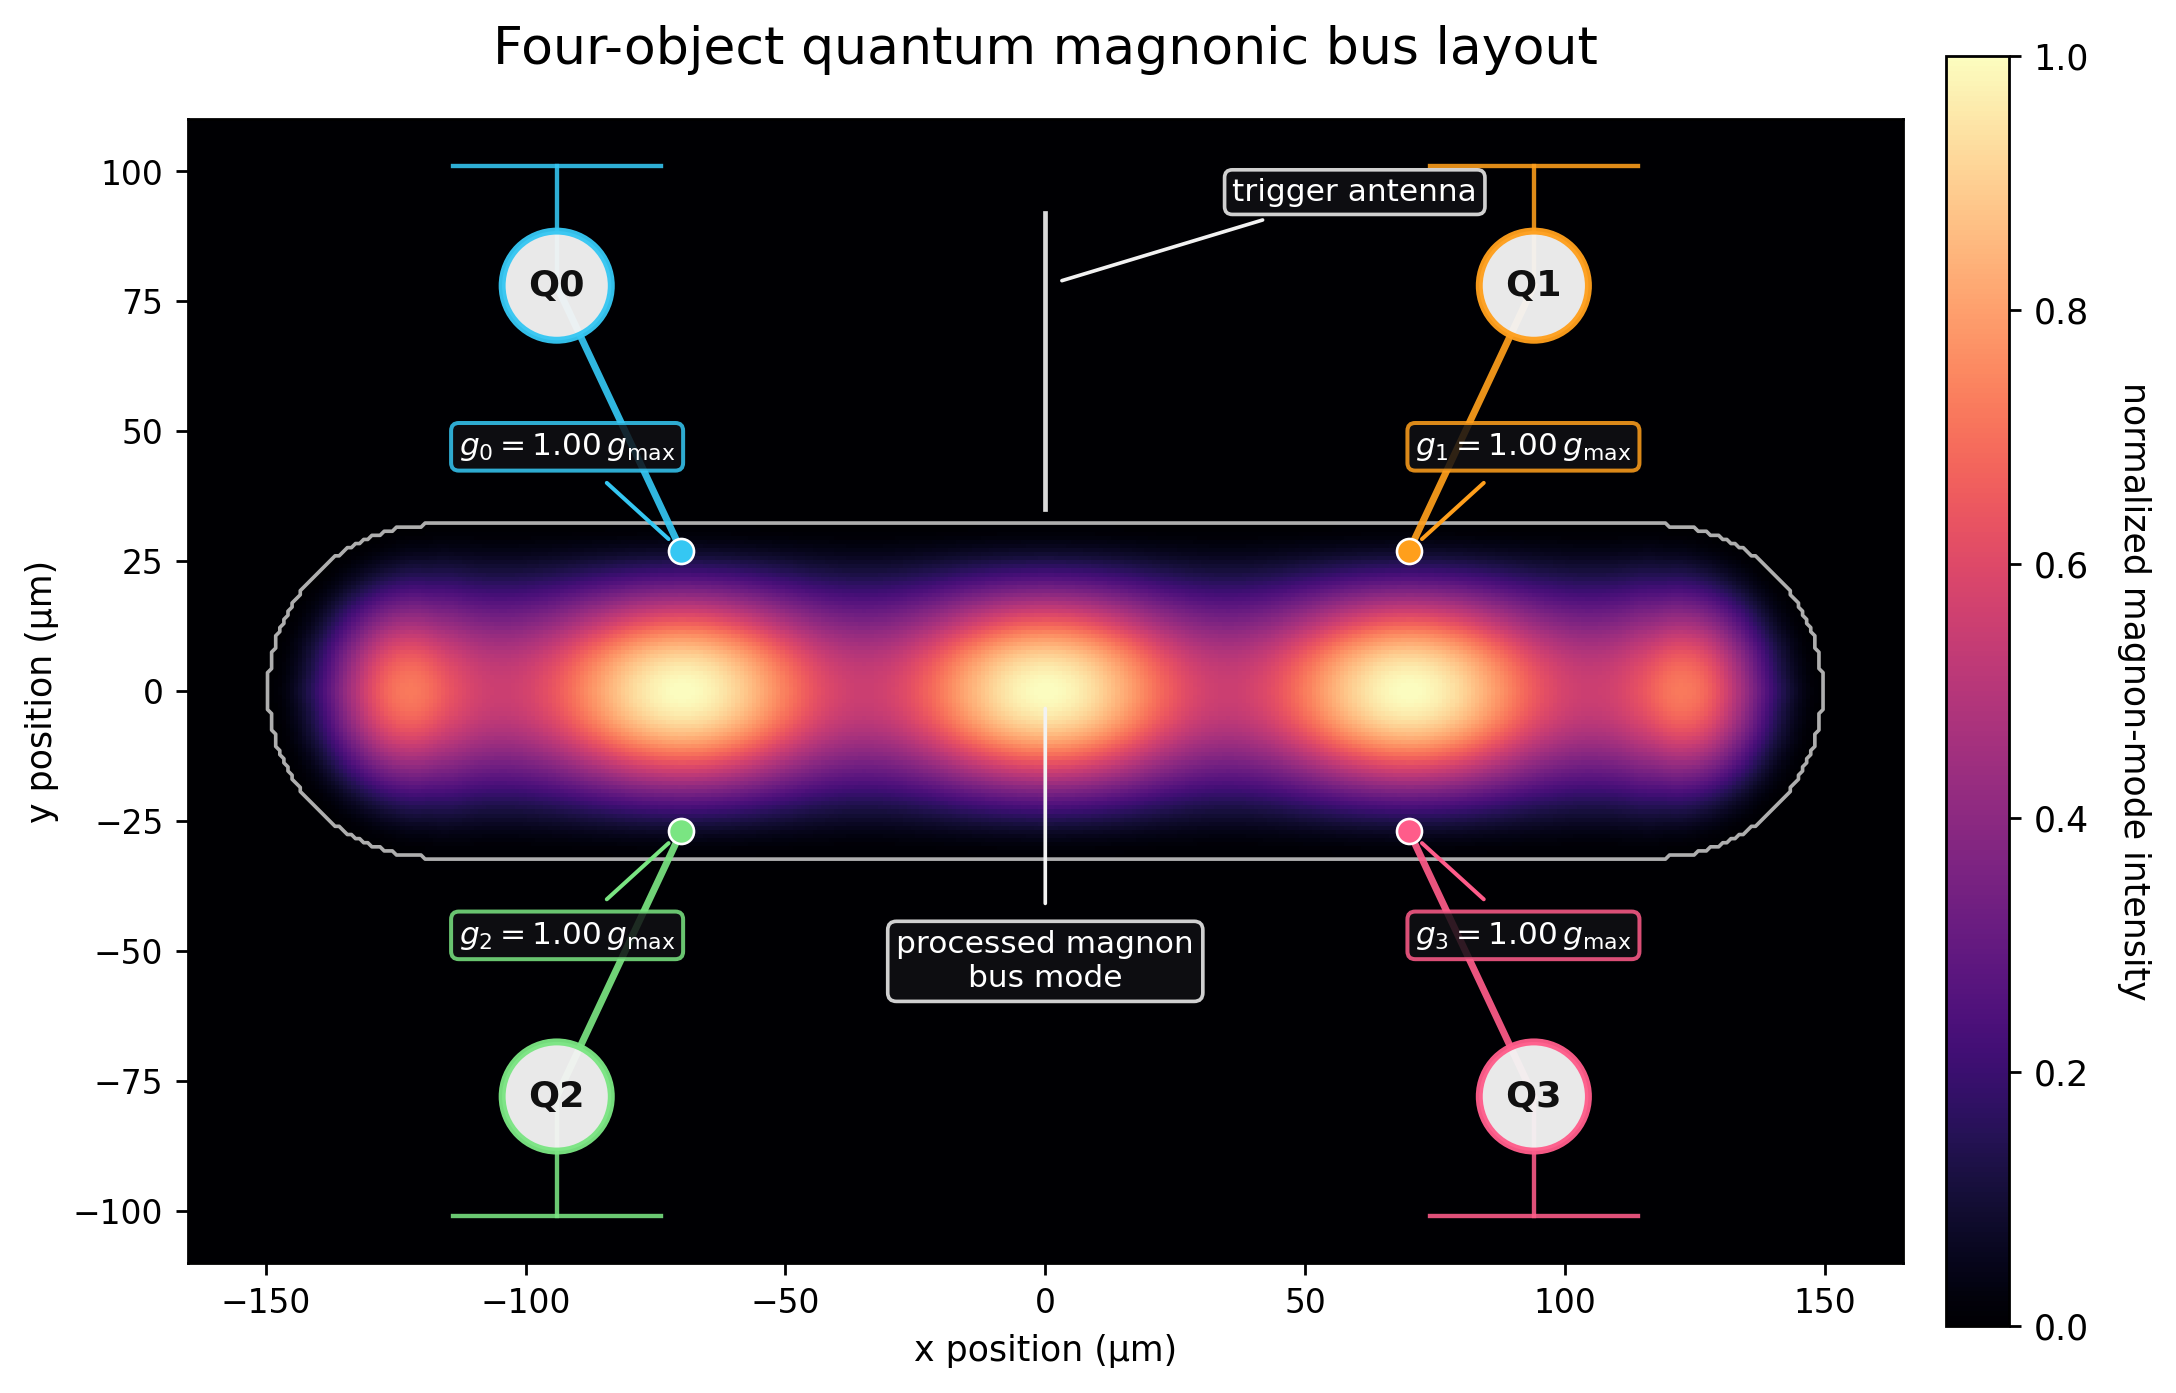

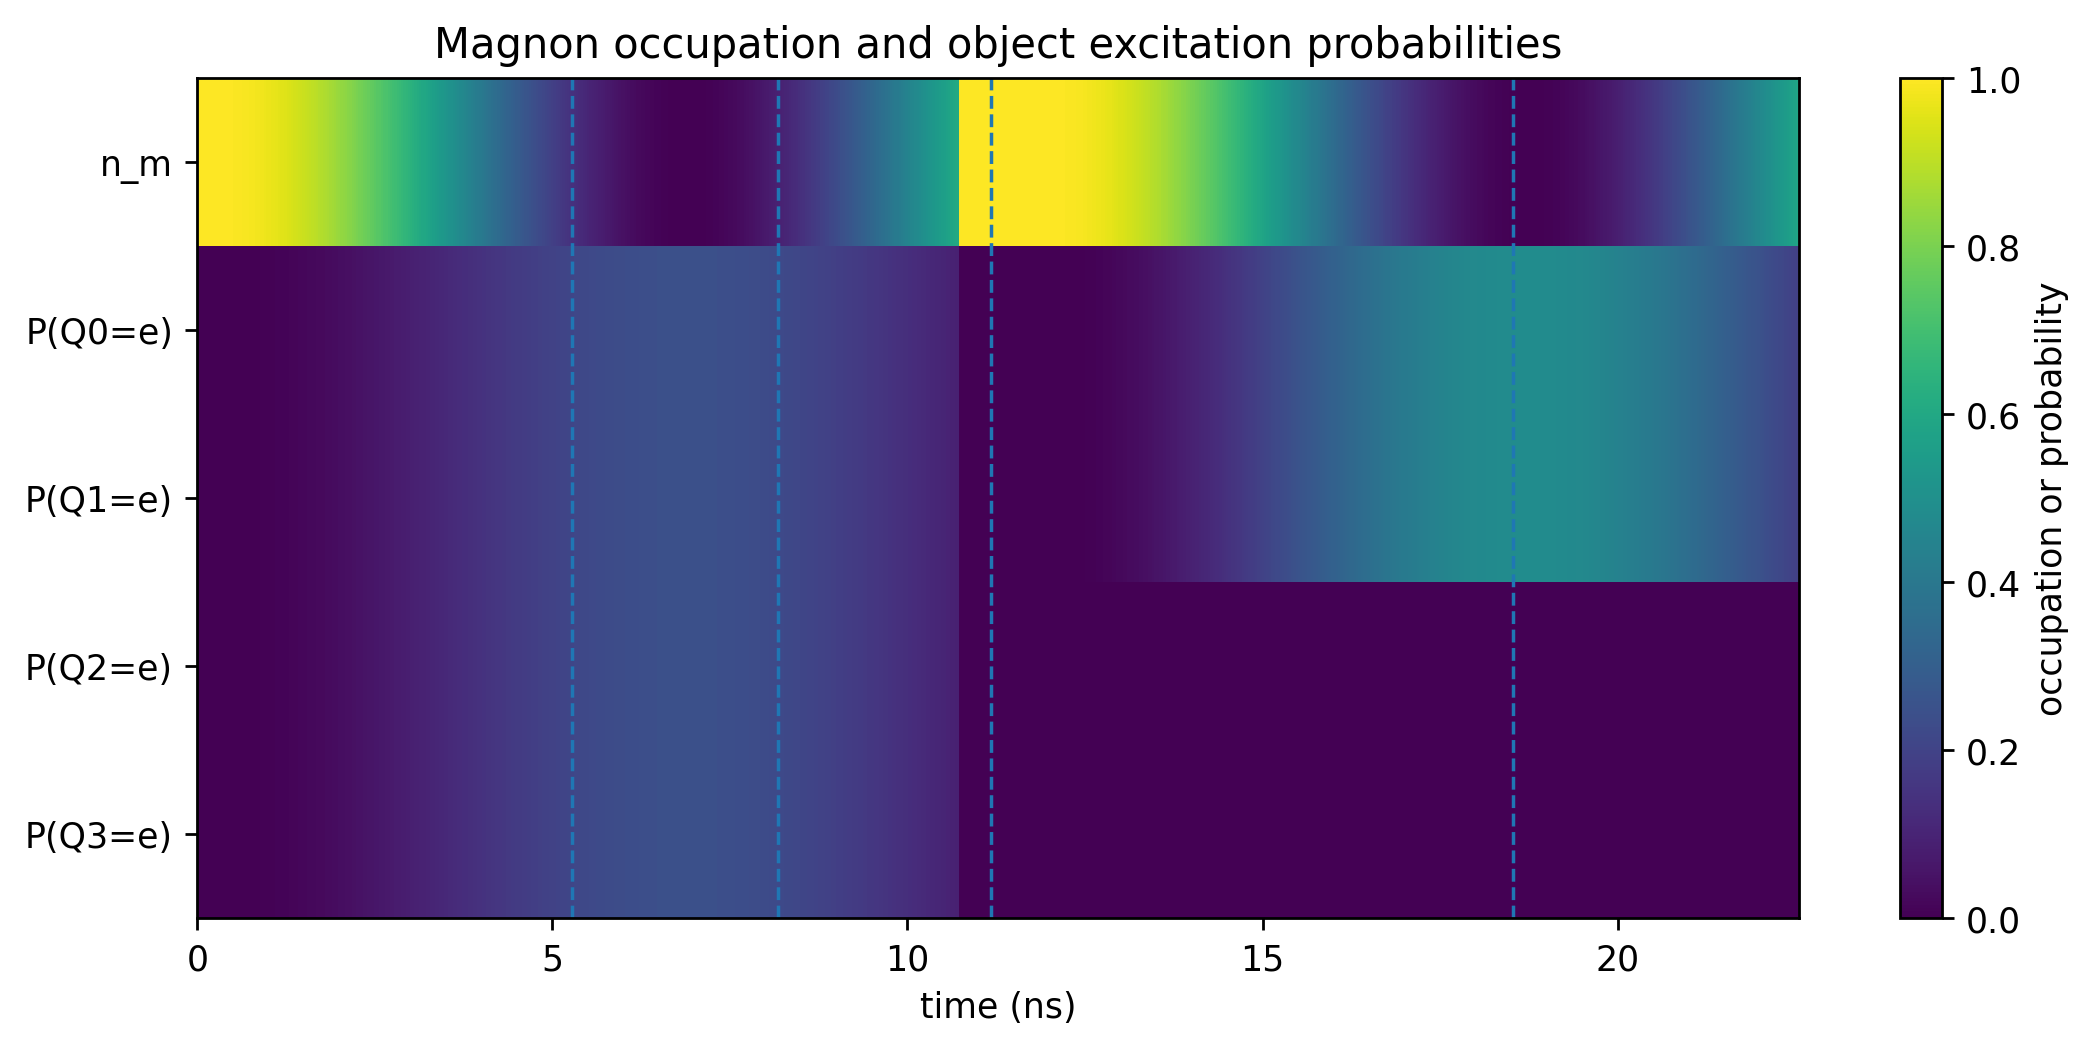

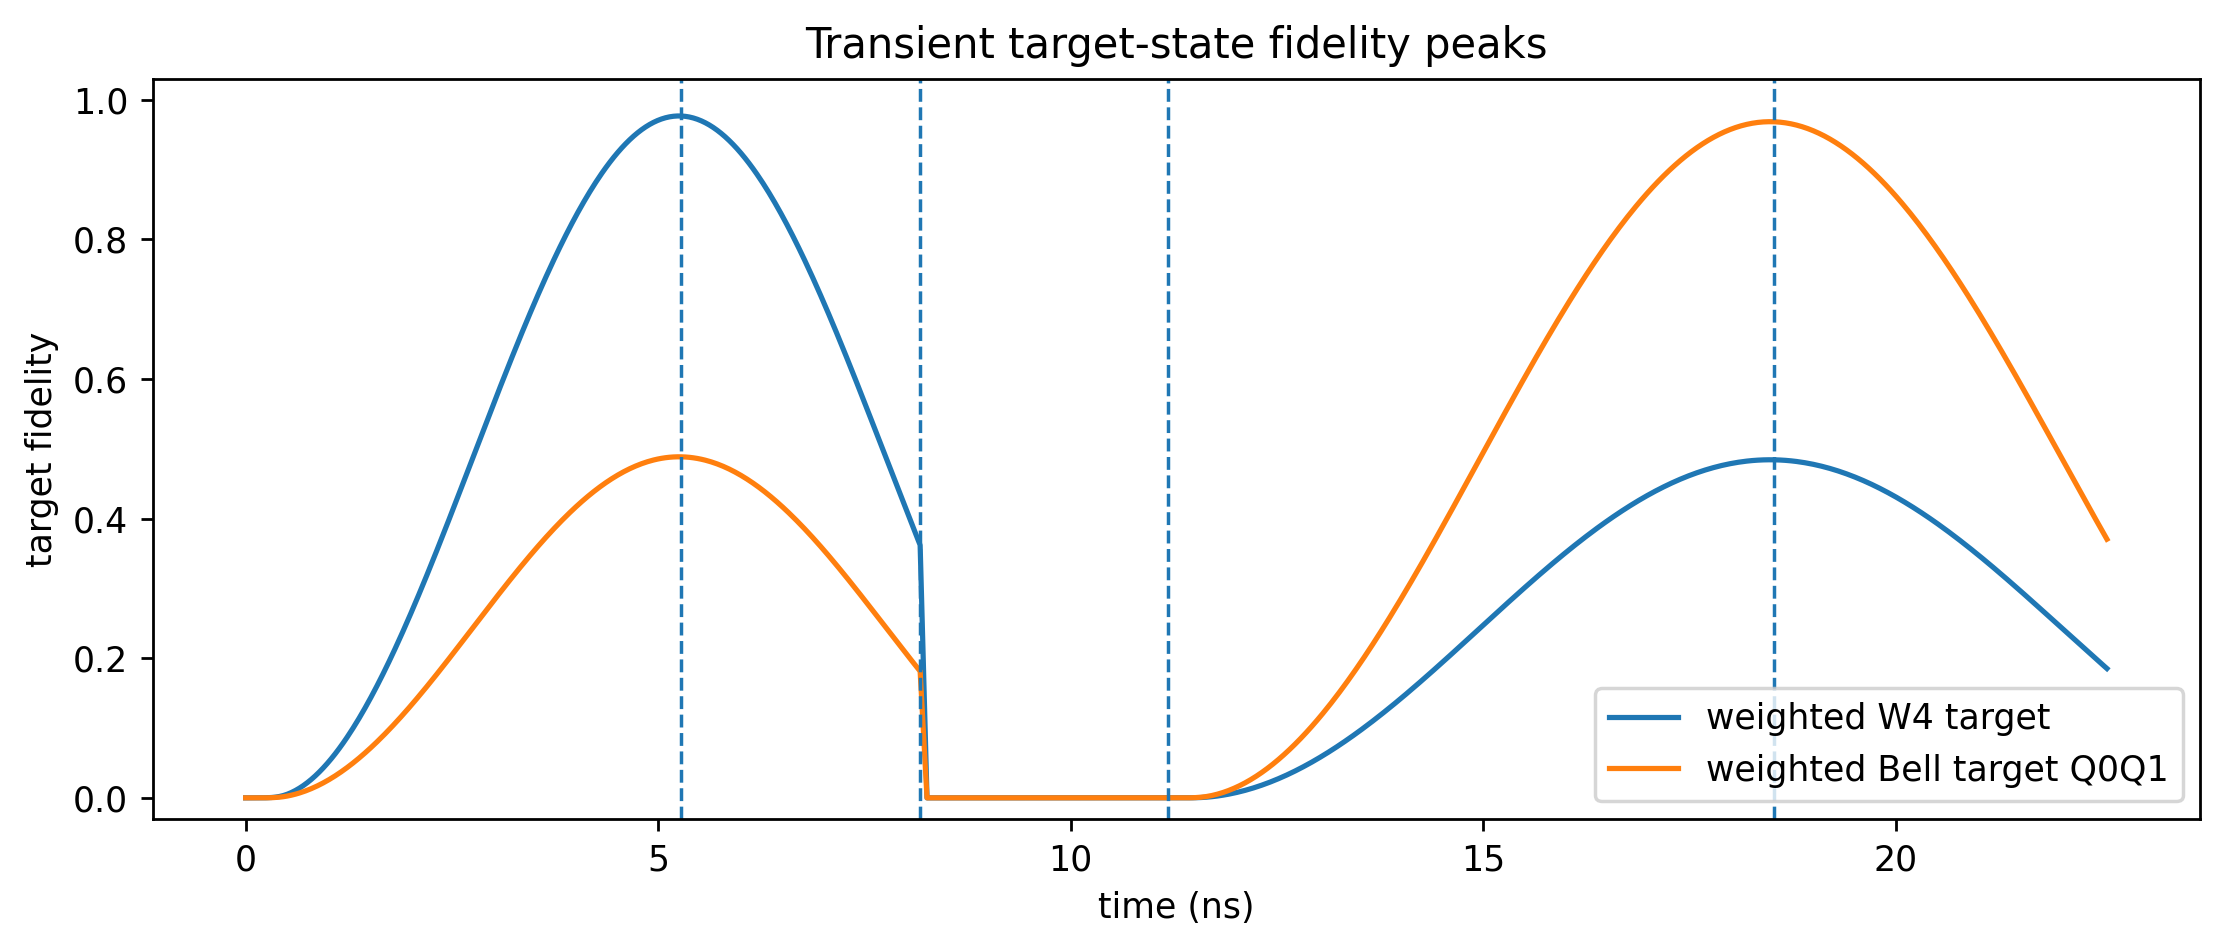

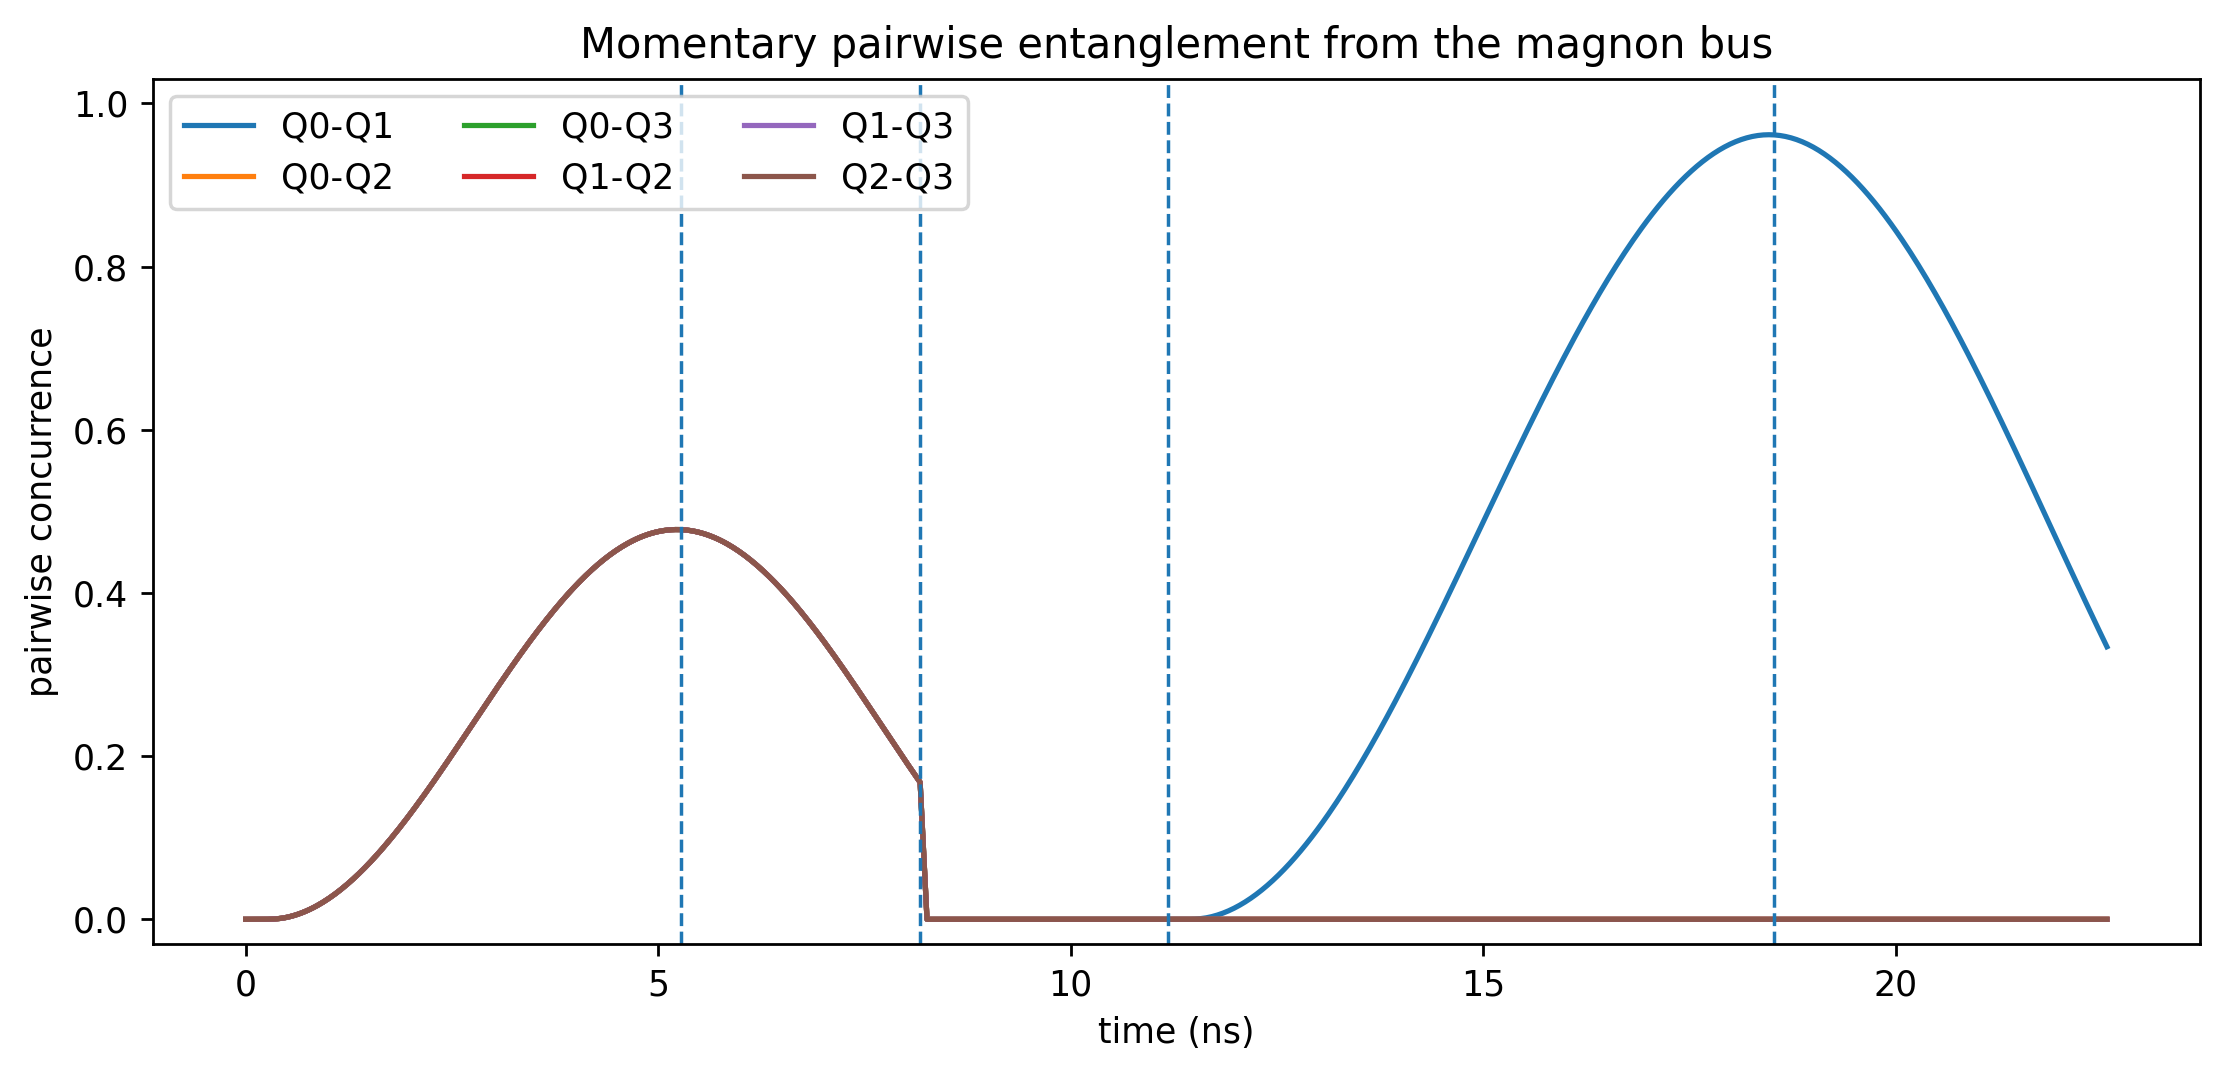

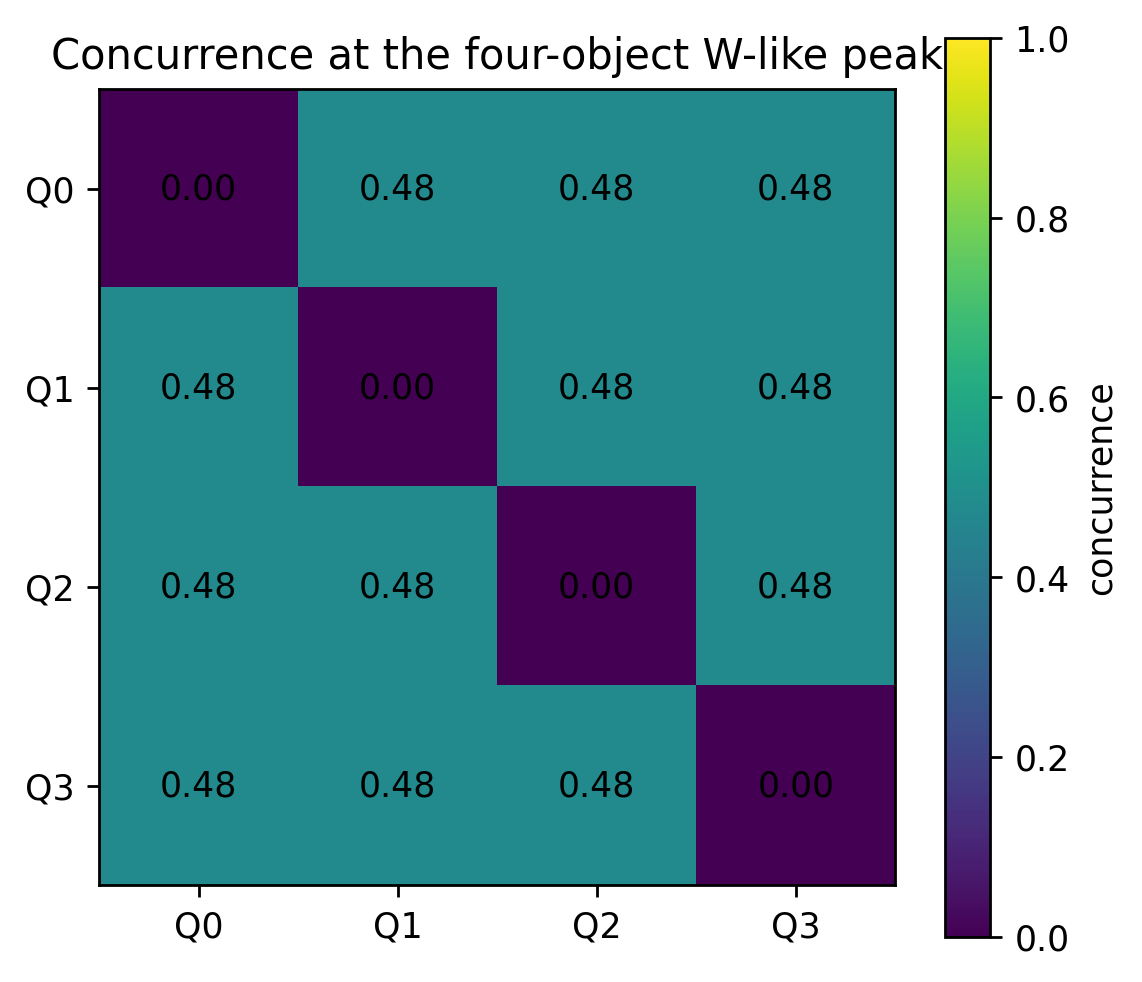

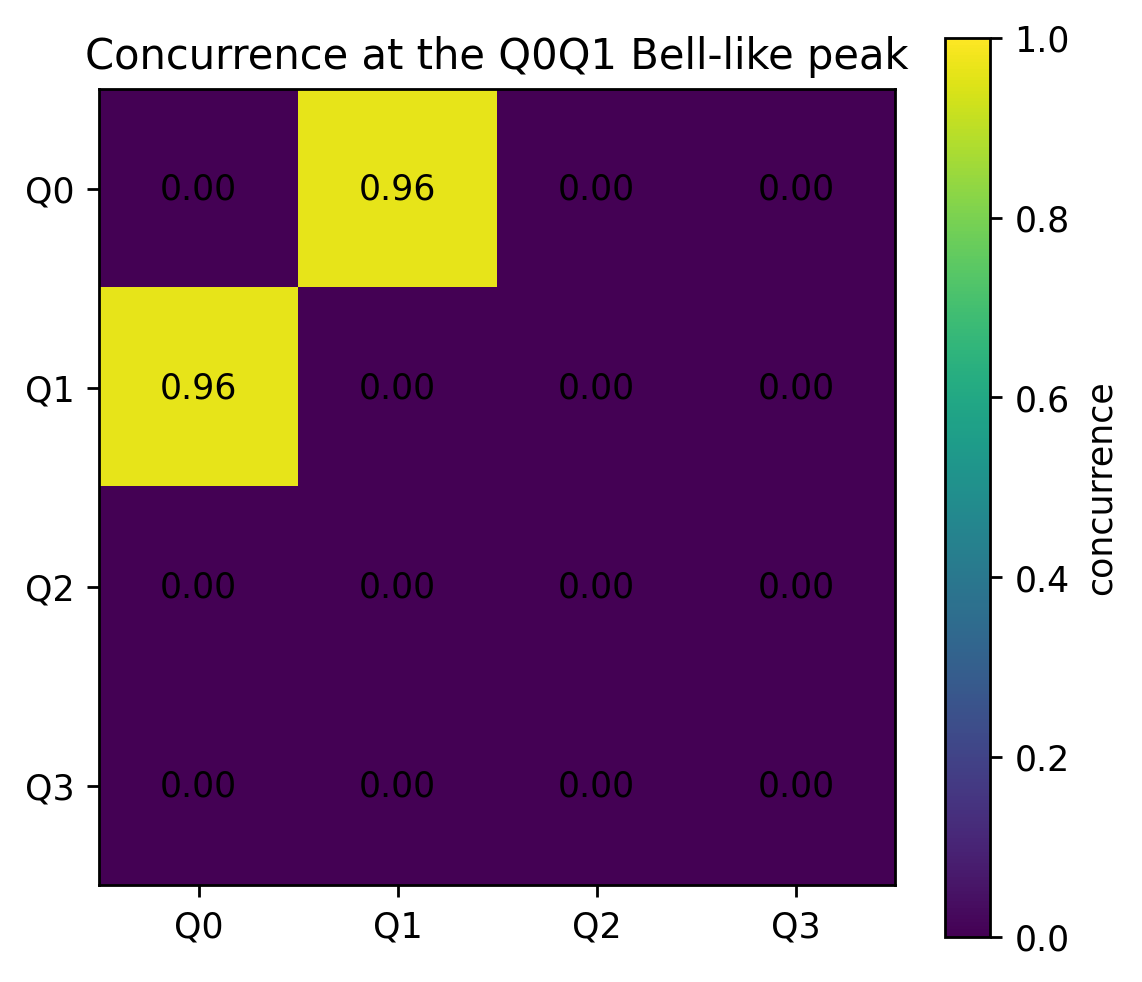

Effective object-bus couplings g_i / 2pi in MHz
Q0: 25.000
Q1: 25.000
Q2: 25.000
Q3: 25.000

Estimated target event times
Stage 1 weighted W4 target: 5.275 ns
Stage 1 reset boundary: 8.176 ns
Stage 2 starts: 11.176 ns
Stage 2 weighted Bell target: 18.522 ns

Observed fidelity peaks
Stage 1 weighted W4 peak: 0.976819 at 5.258 ns
Stage 2 weighted Bell peak: 0.968597 at 18.465 ns

Concurrence matrix at the stage 1 peak
[[0.    0.478 0.478 0.478]
 [0.478 0.    0.478 0.478]
 [0.478 0.478 0.    0.478]
 [0.478 0.478 0.478 0.   ]]

Concurrence matrix at the stage 2 peak
[[0.    0.961 0.    0.   ]
 [0.961 0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]]


In [3]:
"""Open-system simulation of magnon-mediated transient entanglement.

This Colab script designs a four-object quantum magnonic bus layout, processes
its bus region as an image mask, derives spatial object-bus coupling weights,
and simulates two triggered entanglement events with a Lindblad master equation.

The first trigger couples all four objects to the bus and produces a weighted
four-object W-like state. The second trigger reloads the magnon bus and couples
a selected pair to produce a Bell-like state.
"""

from dataclasses import dataclass
from typing import Final, Sequence

import matplotlib.pyplot as plt
import numpy as np
import qutip as qt
from matplotlib import patheffects, rcParams
from matplotlib.patches import Circle
from scipy import ndimage


# ---------------------------------------------------------------------------
# Control knobs.
# ---------------------------------------------------------------------------
FIGURE_DPI: Final[int] = 250
rcParams["figure.dpi"] = FIGURE_DPI

NUM_OBJECTS: Final[int] = 4
N_MAGNON_LEVELS: Final[int] = 3
DIMS: Final[tuple[int, ...]] = (N_MAGNON_LEVELS,) + (2,) * NUM_OBJECTS

SELECTED_PAIR: Final[tuple[int, int]] = (0, 1)

MAX_COUPLING_2PI_MHZ: Final[float] = 25.0
MAGNON_DETUNING_2PI_MHZ: Final[float] = 0.0
OBJECT_DETUNINGS_2PI_MHZ: Final[tuple[float, ...]] = (0.0, 0.0, 0.0, 0.0)

MAGNON_DECAY_2PI_MHZ: Final[float] = 1.2
MAGNON_THERMAL_OCCUPATION: Final[float] = 0.01
OBJECT_RELAXATION_2PI_MHZ: Final[float] = 0.05
OBJECT_PURE_DEPHASING_2PI_MHZ: Final[float] = 0.04

PULSE_RISE_NS: Final[float] = 0.55
STAGE_OBSERVATION_FACTOR: Final[float] = 1.55
RESET_GAP_NS: Final[float] = 3.0

NUM_TIME_SAMPLES_STAGE: Final[int] = 340
NUM_TIME_SAMPLES_RESET: Final[int] = 36
MAX_SOLVER_STEPS: Final[int] = 20000
SOLVER_ATOL: Final[float] = 1.0e-9
SOLVER_RTOL: Final[float] = 1.0e-7

GRID_X_LIMIT_UM: Final[float] = 165.0
GRID_Y_LIMIT_UM: Final[float] = 110.0
GRID_POINTS_X: Final[int] = 420
GRID_POINTS_Y: Final[int] = 280

BUS_LENGTH_UM: Final[float] = 235.0
BUS_WIDTH_UM: Final[float] = 64.0
MODE_WAVELENGTH_UM: Final[float] = 140.0
MODE_SMOOTHING_PIXELS: Final[float] = 1.6

OBJECT_POSITIONS_UM: Final[tuple[tuple[float, float], ...]] = (
    (-94.0, 78.0),
    (94.0, 78.0),
    (-94.0, -78.0),
    (94.0, -78.0),
)

COUPLER_POINTS_UM: Final[tuple[tuple[float, float], ...]] = (
    (-70.0, 27.0),
    (70.0, 27.0),
    (-70.0, -27.0),
    (70.0, -27.0),
)

# Layout-plot visual control knobs.
LAYOUT_COLORMAP_NAME: Final[str] = "magma"
LAYOUT_TITLE_PAD_PT: Final[float] = 16.0
LAYOUT_LABEL_FONT_SIZE: Final[float] = 9.0
LAYOUT_OBJECT_FONT_SIZE: Final[float] = 10.5

OBJECT_COLORS: Final[tuple[str, ...]] = (
    "#35C7F3",
    "#FF9F1C",
    "#7AE582",
    "#FF5C8A",
)

COUPLING_LABEL_OFFSETS_UM: Final[tuple[tuple[float, float], ...]] = (
    (-22.0, 20.0),
    (22.0, 20.0),
    (-22.0, -20.0),
    (22.0, -20.0),
)

LABEL_BOX_FACE_COLOR: Final[str] = "#101014"
LABEL_BOX_ALPHA: Final[float] = 0.86
LABEL_TEXT_STROKE_WIDTH: Final[float] = 2.1


@dataclass(frozen=True)
class Layout:
    """Stores the generated magnonic layout and derived coupling weights."""

    x_um: np.ndarray
    y_um: np.ndarray
    bus_mask: np.ndarray
    mode_intensity: np.ndarray
    mode_amplitude: np.ndarray
    object_positions_um: tuple[tuple[float, float], ...]
    coupler_points_um: tuple[tuple[float, float], ...]
    coupling_weights: np.ndarray


@dataclass(frozen=True)
class Operators:
    """Stores embedded system operators."""

    magnon_lower: qt.Qobj
    magnon_raise: qt.Qobj
    magnon_number: qt.Qobj
    object_lower: tuple[qt.Qobj, ...]
    object_raise: tuple[qt.Qobj, ...]
    object_excited: tuple[qt.Qobj, ...]
    object_z: tuple[qt.Qobj, ...]


@dataclass(frozen=True)
class ProtocolResult:
    """Stores timeline, states, layout, and important event times."""

    times_ns: np.ndarray
    states: list[qt.Qobj]
    layout: Layout
    effective_couplings_rad_per_ns: np.ndarray
    stage_1_target_ns: float
    stage_1_reset_ns: float
    stage_2_start_ns: float
    stage_2_target_ns: float
    stage_2_end_ns: float


@dataclass(frozen=True)
class MetricResult:
    """Stores time-resolved entanglement and excitation observables."""

    magnon_number: np.ndarray
    object_probabilities: np.ndarray
    stage_1_target_fidelity: np.ndarray
    stage_2_target_fidelity: np.ndarray
    pair_concurrence: np.ndarray


def mhz_2pi_to_rad_per_ns(value_mhz: float) -> float:
    """Convert a quoted rate divided by 2pi in MHz to rad/ns.

    Args:
        value_mhz: Frequency or rate quoted as value divided by 2pi in MHz.

    Returns:
        Angular rate in rad/ns.
    """
    return 2.0 * np.pi * value_mhz * 1.0e-3


def rad_per_ns_to_mhz_2pi(value_rad_per_ns: float) -> float:
    """Convert rad/ns to a quoted value divided by 2pi in MHz.

    Args:
        value_rad_per_ns: Angular rate in rad/ns.

    Returns:
        Frequency or rate divided by 2pi in MHz.
    """
    return value_rad_per_ns / (2.0 * np.pi * 1.0e-3)


def make_capsule_mask(
    x_grid_um: np.ndarray,
    y_grid_um: np.ndarray,
) -> np.ndarray:
    """Create a racetrack-shaped magnonic bus mask.

    Args:
        x_grid_um: X-coordinate mesh in micrometers.
        y_grid_um: Y-coordinate mesh in micrometers.

    Returns:
        Boolean image mask for the magnonic material.
    """
    half_length = BUS_LENGTH_UM / 2.0
    radius = BUS_WIDTH_UM / 2.0

    central_strip = (
        (np.abs(x_grid_um) <= half_length)
        & (np.abs(y_grid_um) <= radius)
    )
    left_cap = (x_grid_um + half_length) ** 2 + y_grid_um**2 <= radius**2
    right_cap = (x_grid_um - half_length) ** 2 + y_grid_um**2 <= radius**2

    return central_strip | left_cap | right_cap


def bilinear_sample(
    image: np.ndarray,
    x_values: np.ndarray,
    y_values: np.ndarray,
    point_um: tuple[float, float],
) -> float:
    """Sample an image at a physical point using bilinear interpolation.

    Args:
        image: Image array indexed as [y, x].
        x_values: X-coordinate values for the image columns.
        y_values: Y-coordinate values for the image rows.
        point_um: Physical point in micrometers.

    Returns:
        Interpolated image value.
    """
    x_point, y_point = point_um

    col = np.searchsorted(x_values, x_point) - 1
    row = np.searchsorted(y_values, y_point) - 1

    col = int(np.clip(col, 0, len(x_values) - 2))
    row = int(np.clip(row, 0, len(y_values) - 2))

    x0 = x_values[col]
    x1 = x_values[col + 1]
    y0 = y_values[row]
    y1 = y_values[row + 1]

    tx = (x_point - x0) / (x1 - x0)
    ty = (y_point - y0) / (y1 - y0)

    lower = (1.0 - tx) * image[row, col] + tx * image[row, col + 1]
    upper = (1.0 - tx) * image[row + 1, col] + tx * image[row + 1, col + 1]

    return float((1.0 - ty) * lower + ty * upper)


def make_layout() -> Layout:
    """Generate the layout and process its image mask into a mode profile.

    Returns:
        Layout dataclass with the bus mask, mode image, and coupling weights.
    """
    x_um = np.linspace(-GRID_X_LIMIT_UM, GRID_X_LIMIT_UM, GRID_POINTS_X)
    y_um = np.linspace(-GRID_Y_LIMIT_UM, GRID_Y_LIMIT_UM, GRID_POINTS_Y)
    x_grid, y_grid = np.meshgrid(x_um, y_um)

    bus_mask = make_capsule_mask(x_grid, y_grid)

    dx_um = x_um[1] - x_um[0]
    dy_um = y_um[1] - y_um[0]
    edge_distance_um = ndimage.distance_transform_edt(
        bus_mask,
        sampling=(dy_um, dx_um),
    )

    max_edge_distance_um = np.max(edge_distance_um)
    edge_coordinate = np.clip(edge_distance_um / max_edge_distance_um, 0.0, 1.0)
    transverse_envelope = np.sin(0.5 * np.pi * edge_coordinate) ** 2

    longitudinal_envelope = (
        0.55
        + 0.45 * np.cos(2.0 * np.pi * x_grid / MODE_WAVELENGTH_UM) ** 2
    )

    raw_mode = bus_mask * transverse_envelope * longitudinal_envelope
    mode_intensity = ndimage.gaussian_filter(
        raw_mode,
        sigma=MODE_SMOOTHING_PIXELS,
    )
    mode_intensity = mode_intensity * bus_mask
    mode_intensity = mode_intensity / np.max(mode_intensity)

    mode_amplitude = np.sqrt(np.clip(mode_intensity, 0.0, 1.0))
    sampled_amplitudes = np.array(
        [
            bilinear_sample(mode_amplitude, x_um, y_um, point)
            for point in COUPLER_POINTS_UM
        ],
        dtype=float,
    )

    denominator = np.max(sampled_amplitudes)
    if denominator <= 0.0:
        raise ValueError("Coupler points have zero sampled bus amplitude.")

    coupling_weights = sampled_amplitudes / denominator

    return Layout(
        x_um=x_um,
        y_um=y_um,
        bus_mask=bus_mask,
        mode_intensity=mode_intensity,
        mode_amplitude=mode_amplitude,
        object_positions_um=OBJECT_POSITIONS_UM,
        coupler_points_um=COUPLER_POINTS_UM,
        coupling_weights=coupling_weights,
    )


def embed_operator(local_operator: qt.Qobj, target: int) -> qt.Qobj:
    """Embed a local operator into the full Hilbert space.

    Args:
        local_operator: Local subsystem operator.
        target: Subsystem index, with zero assigned to the magnon bus.

    Returns:
        Tensor-product operator on the full system.
    """
    factors = [qt.qeye(dim) for dim in DIMS]
    factors[target] = local_operator
    return qt.tensor(factors)


def make_operators() -> Operators:
    """Build full-system operators for the bus and four quantum objects.

    Returns:
        Operators dataclass containing embedded operators.
    """
    magnon_lower = embed_operator(qt.destroy(N_MAGNON_LEVELS), target=0)
    magnon_raise = magnon_lower.dag()
    magnon_number = magnon_raise * magnon_lower

    qubit_lower = qt.Qobj(
        np.array([[0.0, 1.0], [0.0, 0.0]], dtype=complex)
    )
    qubit_raise = qubit_lower.dag()
    qubit_excited = qt.basis(2, 1) * qt.basis(2, 1).dag()
    qubit_z = qt.Qobj(
        np.array([[-1.0, 0.0], [0.0, 1.0]], dtype=complex)
    )

    object_lower = tuple(
        embed_operator(qubit_lower, target=index + 1)
        for index in range(NUM_OBJECTS)
    )
    object_raise = tuple(
        embed_operator(qubit_raise, target=index + 1)
        for index in range(NUM_OBJECTS)
    )
    object_excited = tuple(
        embed_operator(qubit_excited, target=index + 1)
        for index in range(NUM_OBJECTS)
    )
    object_z = tuple(
        embed_operator(qubit_z, target=index + 1)
        for index in range(NUM_OBJECTS)
    )

    return Operators(
        magnon_lower=magnon_lower,
        magnon_raise=magnon_raise,
        magnon_number=magnon_number,
        object_lower=object_lower,
        object_raise=object_raise,
        object_excited=object_excited,
        object_z=object_z,
    )


def make_initial_ket() -> qt.Qobj:
    """Create the reloaded initial state with one bus magnon.

    Returns:
        Ket for one magnon in the bus and all objects in the ground state.
    """
    local_states = [qt.basis(N_MAGNON_LEVELS, 1)]
    local_states.extend(qt.basis(2, 0) for _ in range(NUM_OBJECTS))
    return qt.tensor(local_states)


def make_one_object_excited_ket(excited_object: int) -> qt.Qobj:
    """Create a state with one selected object excited and empty bus.

    Args:
        excited_object: Object index carrying the excitation.

    Returns:
        Composite ket.
    """
    local_states = [qt.basis(N_MAGNON_LEVELS, 0)]

    for object_index in range(NUM_OBJECTS):
        level = 1 if object_index == excited_object else 0
        local_states.append(qt.basis(2, level))

    return qt.tensor(local_states)


def make_weighted_single_excitation_target(
    active_objects: Sequence[int],
    coupling_rates: np.ndarray,
) -> qt.Qobj:
    """Create the bright single-excitation target set by active couplings.

    Args:
        active_objects: Object indices included in the target state.
        coupling_rates: Effective object-bus couplings in rad/ns.

    Returns:
        Normalized target ket.
    """
    active_tuple = tuple(active_objects)

    if len(active_tuple) == 0:
        raise ValueError("At least one active object is required.")

    weights = np.array(
        [abs(coupling_rates[index]) for index in active_tuple],
        dtype=float,
    )
    norm = np.linalg.norm(weights)

    if norm <= 0.0:
        raise ValueError("Target state has zero coupling norm.")

    state: qt.Qobj | None = None
    for coefficient, object_index in zip(weights / norm, active_tuple):
        component = coefficient * make_one_object_excited_ket(object_index)
        state = component if state is None else state + component

    if state is None:
        raise ValueError("Target-state construction failed.")

    return state.unit()


def turn_on_coefficient(time_ns: float) -> float:
    """Smoothly turn a trigger pulse from zero to one.

    QuTiP evaluates coefficient callables during QobjEvo construction with a
    single time argument, so this function reads the pulse rise time from the
    module-level control knob instead of an args dictionary.

    Args:
        time_ns: Local stage time in nanoseconds.

    Returns:
        Coupling envelope.
    """
    if time_ns <= 0.0:
        return 0.0

    if time_ns >= PULSE_RISE_NS:
        return 1.0

    return float(0.5 * (1.0 - np.cos(np.pi * time_ns / PULSE_RISE_NS)))


def build_base_hamiltonian(operators: Operators) -> qt.Qobj:
    """Build the detuning terms of the rotating-frame Hamiltonian.

    Args:
        operators: Embedded system operators.

    Returns:
        Time-independent base Hamiltonian.
    """
    hamiltonian = (
        mhz_2pi_to_rad_per_ns(MAGNON_DETUNING_2PI_MHZ)
        * operators.magnon_number
    )

    for index, detuning_mhz in enumerate(OBJECT_DETUNINGS_2PI_MHZ):
        hamiltonian = hamiltonian + (
            mhz_2pi_to_rad_per_ns(detuning_mhz)
            * operators.object_excited[index]
        )

    return hamiltonian


def build_stage_hamiltonian(
    operators: Operators,
    effective_couplings_rad_per_ns: np.ndarray,
    active_objects: Sequence[int],
) -> list[qt.Qobj | list[object]]:
    """Build a triggered stage Hamiltonian.

    Args:
        operators: Embedded system operators.
        effective_couplings_rad_per_ns: Object-bus couplings in rad/ns.
        active_objects: Object indices coupled during this stage.

    Returns:
        QuTiP Hamiltonian list with time-dependent coupling envelopes.
    """
    hamiltonian: list[qt.Qobj | list[object]] = [build_base_hamiltonian(operators)]

    for object_index in active_objects:
        interaction = effective_couplings_rad_per_ns[object_index] * (
            operators.magnon_lower * operators.object_raise[object_index]
            + operators.magnon_raise * operators.object_lower[object_index]
        )
        hamiltonian.append([interaction, turn_on_coefficient])

    return hamiltonian


def build_collapse_operators(operators: Operators) -> list[qt.Qobj]:
    """Build Lindblad collapse operators for the open-system model.

    Args:
        operators: Embedded system operators.

    Returns:
        Collapse operators for magnon decay, heating, relaxation, and dephasing.
    """
    collapse_operators: list[qt.Qobj] = []

    magnon_decay = mhz_2pi_to_rad_per_ns(MAGNON_DECAY_2PI_MHZ)
    qubit_relaxation = mhz_2pi_to_rad_per_ns(OBJECT_RELAXATION_2PI_MHZ)
    qubit_dephasing = mhz_2pi_to_rad_per_ns(OBJECT_PURE_DEPHASING_2PI_MHZ)

    if magnon_decay > 0.0:
        collapse_operators.append(
            np.sqrt(magnon_decay * (MAGNON_THERMAL_OCCUPATION + 1.0))
            * operators.magnon_lower
        )
        if MAGNON_THERMAL_OCCUPATION > 0.0:
            collapse_operators.append(
                np.sqrt(magnon_decay * MAGNON_THERMAL_OCCUPATION)
                * operators.magnon_raise
            )

    for object_index in range(NUM_OBJECTS):
        if qubit_relaxation > 0.0:
            collapse_operators.append(
                np.sqrt(qubit_relaxation) * operators.object_lower[object_index]
            )

        if qubit_dephasing > 0.0:
            collapse_operators.append(
                np.sqrt(qubit_dephasing / 2.0)
                * operators.object_z[object_index]
            )

    return collapse_operators


def estimate_transfer_time_ns(
    active_objects: Sequence[int],
    effective_couplings_rad_per_ns: np.ndarray,
) -> float:
    """Estimate the first bus-to-object bright-state transfer time.

    Args:
        active_objects: Object indices coupled during a stage.
        effective_couplings_rad_per_ns: Object-bus couplings in rad/ns.

    Returns:
        Estimated transfer time in nanoseconds.
    """
    active_couplings = np.array(
        [effective_couplings_rad_per_ns[index] for index in active_objects],
        dtype=float,
    )
    bright_rate = np.linalg.norm(active_couplings)

    if bright_rate <= 0.0:
        raise ValueError("Active coupling norm is zero.")

    ideal_time_ns = np.pi / (2.0 * bright_rate)
    return ideal_time_ns + 0.5 * PULSE_RISE_NS


def simulate_stage(
    operators: Operators,
    active_objects: Sequence[int],
    initial_density_matrix: qt.Qobj,
    effective_couplings_rad_per_ns: np.ndarray,
    duration_ns: float,
) -> tuple[np.ndarray, list[qt.Qobj]]:
    """Simulate one triggered entanglement stage.

    Args:
        operators: Embedded system operators.
        active_objects: Object indices coupled during this stage.
        initial_density_matrix: Initial density matrix.
        effective_couplings_rad_per_ns: Object-bus couplings in rad/ns.
        duration_ns: Local simulation duration in nanoseconds.

    Returns:
        Local times and density matrices.
    """
    times_ns = np.linspace(0.0, duration_ns, NUM_TIME_SAMPLES_STAGE)
    hamiltonian = build_stage_hamiltonian(
        operators=operators,
        effective_couplings_rad_per_ns=effective_couplings_rad_per_ns,
        active_objects=active_objects,
    )
    collapse_operators = build_collapse_operators(operators)

    solver_options = {
        "store_states": True,
        "nsteps": MAX_SOLVER_STEPS,
        "atol": SOLVER_ATOL,
        "rtol": SOLVER_RTOL,
    }

    result = qt.mesolve(
        H=hamiltonian,
        rho0=initial_density_matrix,
        tlist=times_ns,
        c_ops=collapse_operators,
        e_ops=[],
        options=solver_options,
    )

    return times_ns, list(result.states)


def run_protocol() -> ProtocolResult:
    """Run both entanglement triggers with active reset and reload.

    Returns:
        ProtocolResult with the full concatenated timeline.
    """
    layout = make_layout()
    operators = make_operators()

    max_coupling = mhz_2pi_to_rad_per_ns(MAX_COUPLING_2PI_MHZ)
    effective_couplings = max_coupling * layout.coupling_weights

    reloaded_ket = make_initial_ket()
    reloaded_density_matrix = qt.ket2dm(reloaded_ket)

    stage_1_active = tuple(range(NUM_OBJECTS))
    stage_2_active = SELECTED_PAIR

    stage_1_target_ns = estimate_transfer_time_ns(
        stage_1_active,
        effective_couplings,
    )
    stage_2_target_local_ns = estimate_transfer_time_ns(
        stage_2_active,
        effective_couplings,
    )

    stage_1_duration_ns = STAGE_OBSERVATION_FACTOR * stage_1_target_ns
    stage_2_duration_ns = STAGE_OBSERVATION_FACTOR * stage_2_target_local_ns

    stage_1_times, stage_1_states = simulate_stage(
        operators=operators,
        active_objects=stage_1_active,
        initial_density_matrix=reloaded_density_matrix,
        effective_couplings_rad_per_ns=effective_couplings,
        duration_ns=stage_1_duration_ns,
    )

    stage_1_reset_ns = stage_1_duration_ns
    stage_2_start_ns = stage_1_reset_ns + RESET_GAP_NS

    reset_times = np.linspace(
        stage_1_reset_ns,
        stage_2_start_ns,
        NUM_TIME_SAMPLES_RESET + 1,
    )[1:]
    reset_states = [
        reloaded_density_matrix.copy()
        for _ in range(reset_times.size)
    ]

    stage_2_times_local, stage_2_states = simulate_stage(
        operators=operators,
        active_objects=stage_2_active,
        initial_density_matrix=reloaded_density_matrix,
        effective_couplings_rad_per_ns=effective_couplings,
        duration_ns=stage_2_duration_ns,
    )

    stage_2_times = stage_2_start_ns + stage_2_times_local[1:]
    stage_2_target_ns = stage_2_start_ns + stage_2_target_local_ns
    stage_2_end_ns = stage_2_start_ns + stage_2_duration_ns

    all_times = np.concatenate((stage_1_times, reset_times, stage_2_times))
    all_states = stage_1_states + reset_states + stage_2_states[1:]

    return ProtocolResult(
        times_ns=all_times,
        states=all_states,
        layout=layout,
        effective_couplings_rad_per_ns=effective_couplings,
        stage_1_target_ns=stage_1_target_ns,
        stage_1_reset_ns=stage_1_reset_ns,
        stage_2_start_ns=stage_2_start_ns,
        stage_2_target_ns=stage_2_target_ns,
        stage_2_end_ns=stage_2_end_ns,
    )


def pure_target_overlap(density_matrix: qt.Qobj, target: qt.Qobj) -> float:
    """Compute overlap between a density matrix and a pure target state.

    Args:
        density_matrix: Density matrix.
        target: Pure target ket.

    Returns:
        Target-state population.
    """
    value = target.dag() * density_matrix * target

    if isinstance(value, qt.Qobj):
        scalar_value = value.full()[0, 0]
    else:
        scalar_value = complex(value)

    return float(np.clip(np.real(scalar_value), 0.0, 1.0))


def concurrence(two_qubit_density_matrix: np.ndarray) -> float:
    """Compute Wootters concurrence for a two-qubit density matrix.

    Args:
        two_qubit_density_matrix: Four-by-four reduced density matrix.

    Returns:
        Pairwise concurrence.
    """
    sigma_y = np.array([[0.0, -1j], [1j, 0.0]], dtype=complex)
    spin_flip = np.kron(sigma_y, sigma_y)

    rho = two_qubit_density_matrix
    matrix = rho @ spin_flip @ rho.conj() @ spin_flip
    eigenvalues = np.linalg.eigvals(matrix)
    roots = np.sqrt(np.clip(np.real(eigenvalues), 0.0, None))
    roots = np.sort(roots)[::-1]

    return float(np.clip(roots[0] - np.sum(roots[1:]), 0.0, 1.0))


def compute_metrics(
    result: ProtocolResult,
    operators: Operators,
) -> MetricResult:
    """Compute excitation probabilities, fidelities, and concurrence.

    Args:
        result: Full protocol result.
        operators: Embedded system operators.

    Returns:
        Time-resolved metrics.
    """
    stage_1_target = make_weighted_single_excitation_target(
        active_objects=tuple(range(NUM_OBJECTS)),
        coupling_rates=result.effective_couplings_rad_per_ns,
    )
    stage_2_target = make_weighted_single_excitation_target(
        active_objects=SELECTED_PAIR,
        coupling_rates=result.effective_couplings_rad_per_ns,
    )

    num_times = len(result.states)
    magnon_number = np.zeros(num_times)
    object_probabilities = np.zeros((num_times, NUM_OBJECTS))
    stage_1_target_fidelity = np.zeros(num_times)
    stage_2_target_fidelity = np.zeros(num_times)
    pair_concurrence = np.zeros((num_times, NUM_OBJECTS, NUM_OBJECTS))

    for time_index, density_matrix in enumerate(result.states):
        magnon_number[time_index] = float(
            np.real(qt.expect(operators.magnon_number, density_matrix))
        )

        for object_index in range(NUM_OBJECTS):
            object_probabilities[time_index, object_index] = float(
                np.real(
                    qt.expect(
                        operators.object_excited[object_index],
                        density_matrix,
                    )
                )
            )

        stage_1_target_fidelity[time_index] = pure_target_overlap(
            density_matrix,
            stage_1_target,
        )
        stage_2_target_fidelity[time_index] = pure_target_overlap(
            density_matrix,
            stage_2_target,
        )

        for first_object in range(NUM_OBJECTS):
            for second_object in range(first_object + 1, NUM_OBJECTS):
                reduced_state = density_matrix.ptrace(
                    [first_object + 1, second_object + 1]
                )
                value = concurrence(reduced_state.full())
                pair_concurrence[time_index, first_object, second_object] = value
                pair_concurrence[time_index, second_object, first_object] = value

    return MetricResult(
        magnon_number=magnon_number,
        object_probabilities=object_probabilities,
        stage_1_target_fidelity=stage_1_target_fidelity,
        stage_2_target_fidelity=stage_2_target_fidelity,
        pair_concurrence=pair_concurrence,
    )


def find_stage_peak_indices(
    result: ProtocolResult,
    metrics: MetricResult,
) -> tuple[int, int]:
    """Find peak target-fidelity indices for the two stages.

    Args:
        result: Full protocol result.
        metrics: Computed metrics.

    Returns:
        Stage-one and stage-two peak indices.
    """
    stage_1_indices = np.flatnonzero(result.times_ns <= result.stage_1_reset_ns)
    stage_2_indices = np.flatnonzero(result.times_ns >= result.stage_2_start_ns)

    stage_1_peak = stage_1_indices[
        np.argmax(metrics.stage_1_target_fidelity[stage_1_indices])
    ]
    stage_2_peak = stage_2_indices[
        np.argmax(metrics.stage_2_target_fidelity[stage_2_indices])
    ]

    return int(stage_1_peak), int(stage_2_peak)


def add_event_lines(ax: plt.Axes, result: ProtocolResult) -> None:
    """Add vertical event markers to a time-domain plot.

    Args:
        ax: Matplotlib axes.
        result: Full protocol result.
    """
    event_times = (
        result.stage_1_target_ns,
        result.stage_1_reset_ns,
        result.stage_2_start_ns,
        result.stage_2_target_ns,
    )

    for event_time in event_times:
        ax.axvline(event_time, linestyle="--", linewidth=1.0)


def plot_circuit_layout(layout: Layout) -> None:
    """Render the procedurally generated magnonic bus circuit.

    Args:
        layout: Generated layout and mode image.
    """
    extent = (
        layout.x_um[0],
        layout.x_um[-1],
        layout.y_um[0],
        layout.y_um[-1],
    )

    fig, ax = plt.subplots(figsize=(8.6, 5.5), constrained_layout=True)
    ax.set_facecolor("#050508")

    image = ax.imshow(
        layout.mode_intensity,
        extent=extent,
        origin="lower",
        interpolation="nearest",
        cmap=LAYOUT_COLORMAP_NAME,
        vmin=0.0,
        vmax=1.0,
        zorder=0,
    )

    ax.contour(
        layout.x_um,
        layout.y_um,
        layout.bus_mask.astype(float),
        levels=[0.5],
        colors="#F2F2F2",
        linewidths=1.05,
        alpha=0.72,
        zorder=2,
    )

    for object_index, ((object_x, object_y), (coupler_x, coupler_y)) in enumerate(
        zip(layout.object_positions_um, layout.coupler_points_um)
    ):
        color = OBJECT_COLORS[object_index % len(OBJECT_COLORS)]

        ax.plot(
            [object_x, coupler_x],
            [object_y, coupler_y],
            color=color,
            linewidth=2.0,
            alpha=0.92,
            zorder=4,
        )
        ax.scatter(
            [coupler_x],
            [coupler_y],
            s=52,
            color=color,
            edgecolor="white",
            linewidth=0.75,
            zorder=6,
        )

        circle = Circle(
            (object_x, object_y),
            radius=10.5,
            facecolor="#F4F4F4",
            edgecolor=color,
            linewidth=2.0,
            alpha=0.96,
            zorder=5,
        )
        ax.add_patch(circle)
        ax.text(
            object_x,
            object_y,
            f"Q{object_index}",
            ha="center",
            va="center",
            fontsize=LAYOUT_OBJECT_FONT_SIZE,
            fontweight="bold",
            color="#101010",
            zorder=7,
        )

        guide_y = object_y + np.sign(object_y) * 23.0
        ax.plot(
            [object_x, object_x],
            [object_y, guide_y],
            color=color,
            linewidth=1.25,
            alpha=0.88,
            zorder=3,
        )
        ax.plot(
            [object_x - 20.0, object_x + 20.0],
            [guide_y, guide_y],
            color=color,
            linewidth=1.25,
            alpha=0.88,
            zorder=3,
        )

        label_dx, label_dy = COUPLING_LABEL_OFFSETS_UM[object_index]
        label_x = coupler_x + label_dx
        label_y = coupler_y + label_dy
        label_text = (
            rf"$g_{{{object_index}}} = "
            rf"{layout.coupling_weights[object_index]:.2f}\,g_\mathrm{{max}}$"
        )

        ax.annotate(
            label_text,
            xy=(coupler_x, coupler_y),
            xytext=(label_x, label_y),
            textcoords="data",
            ha="center",
            va="center",
            fontsize=LAYOUT_LABEL_FONT_SIZE,
            color="white",
            zorder=9,
            bbox={
                "boxstyle": "round,pad=0.25",
                "facecolor": LABEL_BOX_FACE_COLOR,
                "edgecolor": color,
                "alpha": LABEL_BOX_ALPHA,
                "linewidth": 1.15,
            },
            arrowprops={
                "arrowstyle": "-",
                "color": color,
                "linewidth": 1.15,
                "shrinkA": 5.0,
                "shrinkB": 5.0,
            },
        )

    antenna_color = "#F2F2F2"
    ax.plot(
        [0.0, 0.0],
        [92.0, 35.0],
        color=antenna_color,
        linewidth=1.35,
        alpha=0.90,
        zorder=4,
    )
    ax.annotate(
        "trigger antenna",
        xy=(0.0, 78.0),
        xytext=(36.0, 96.0),
        textcoords="data",
        ha="left",
        va="center",
        fontsize=LAYOUT_LABEL_FONT_SIZE,
        color="white",
        zorder=10,
        bbox={
            "boxstyle": "round,pad=0.25",
            "facecolor": LABEL_BOX_FACE_COLOR,
            "edgecolor": antenna_color,
            "alpha": LABEL_BOX_ALPHA,
            "linewidth": 1.05,
        },
        arrowprops={
            "arrowstyle": "-",
            "color": antenna_color,
            "linewidth": 1.05,
            "shrinkA": 5.0,
            "shrinkB": 5.0,
        },
    )

    ax.annotate(
        "processed magnon\nbus mode",
        xy=(0.0, 0.0),
        xytext=(0.0, -52.0),
        textcoords="data",
        ha="center",
        va="center",
        fontsize=LAYOUT_LABEL_FONT_SIZE,
        color="white",
        zorder=10,
        bbox={
            "boxstyle": "round,pad=0.28",
            "facecolor": LABEL_BOX_FACE_COLOR,
            "edgecolor": "#F2F2F2",
            "alpha": LABEL_BOX_ALPHA,
            "linewidth": 1.05,
        },
        arrowprops={
            "arrowstyle": "-",
            "color": "#F2F2F2",
            "linewidth": 1.05,
            "shrinkA": 5.0,
            "shrinkB": 5.0,
        },
    )

    ax.set_xlabel("x position (µm)")
    ax.set_ylabel("y position (µm)")
    ax.set_title(
        "Four-object quantum magnonic bus layout",
        pad=LAYOUT_TITLE_PAD_PT,
        fontsize=15.0,
    )
    ax.set_aspect("equal", adjustable="box")
    ax.tick_params(labelsize=9.5)

    colorbar = fig.colorbar(image, ax=ax, pad=0.025)
    colorbar.set_label(
        "normalized magnon-mode intensity",
        rotation=270,
        labelpad=18.0,
    )

    plt.show()


def plot_excitation_heatmap(
    result: ProtocolResult,
    metrics: MetricResult,
) -> None:
    """Render bus occupation and object excitation probabilities.

    Args:
        result: Full protocol result.
        metrics: Computed metrics.
    """
    row_labels = ["n_m"] + [f"P(Q{index}=e)" for index in range(NUM_OBJECTS)]
    heatmap_data = np.vstack(
        (metrics.magnon_number, metrics.object_probabilities.T)
    )

    fig, ax = plt.subplots(figsize=(9.0, 4.3))
    image = ax.imshow(
        heatmap_data,
        aspect="auto",
        interpolation="nearest",
        extent=(
            result.times_ns[0],
            result.times_ns[-1],
            len(row_labels) - 0.5,
            -0.5,
        ),
        vmin=0.0,
        vmax=1.0,
    )
    add_event_lines(ax, result)

    ax.set_yticks(np.arange(len(row_labels)), row_labels)
    ax.set_xlabel("time (ns)")
    ax.set_title("Magnon occupation and object excitation probabilities")
    fig.colorbar(image, ax=ax, label="occupation or probability")
    plt.tight_layout()
    plt.show()


def plot_target_fidelities(
    result: ProtocolResult,
    metrics: MetricResult,
) -> None:
    """Render target-state fidelities across both trigger windows.

    Args:
        result: Full protocol result.
        metrics: Computed metrics.
    """
    fig, ax = plt.subplots(figsize=(9.0, 3.9))
    ax.plot(
        result.times_ns,
        metrics.stage_1_target_fidelity,
        label="weighted W4 target",
    )
    ax.plot(
        result.times_ns,
        metrics.stage_2_target_fidelity,
        label=f"weighted Bell target Q{SELECTED_PAIR[0]}Q{SELECTED_PAIR[1]}",
    )
    add_event_lines(ax, result)

    ax.set_xlabel("time (ns)")
    ax.set_ylabel("target fidelity")
    ax.set_ylim(-0.03, 1.03)
    ax.set_title("Transient target-state fidelity peaks")
    ax.legend()
    plt.tight_layout()
    plt.show()


def plot_concurrence_traces(
    result: ProtocolResult,
    metrics: MetricResult,
) -> None:
    """Render pairwise concurrence traces.

    Args:
        result: Full protocol result.
        metrics: Computed metrics.
    """
    fig, ax = plt.subplots(figsize=(9.0, 4.4))

    for first_object in range(NUM_OBJECTS):
        for second_object in range(first_object + 1, NUM_OBJECTS):
            ax.plot(
                result.times_ns,
                metrics.pair_concurrence[:, first_object, second_object],
                label=f"Q{first_object}-Q{second_object}",
            )

    add_event_lines(ax, result)

    ax.set_xlabel("time (ns)")
    ax.set_ylabel("pairwise concurrence")
    ax.set_ylim(-0.03, 1.03)
    ax.set_title("Momentary pairwise entanglement from the magnon bus")
    ax.legend(ncol=3)
    plt.tight_layout()
    plt.show()


def plot_concurrence_matrix(matrix: np.ndarray, title: str) -> None:
    """Render a concurrence matrix.

    Args:
        matrix: Pairwise concurrence matrix.
        title: Figure title.
    """
    labels = [f"Q{index}" for index in range(NUM_OBJECTS)]

    fig, ax = plt.subplots(figsize=(4.7, 4.1))
    image = ax.imshow(matrix, interpolation="nearest", vmin=0.0, vmax=1.0)

    ax.set_xticks(np.arange(NUM_OBJECTS), labels)
    ax.set_yticks(np.arange(NUM_OBJECTS), labels)
    ax.set_title(title)

    for row in range(NUM_OBJECTS):
        for col in range(NUM_OBJECTS):
            ax.text(
                col,
                row,
                f"{matrix[row, col]:.2f}",
                ha="center",
                va="center",
            )

    fig.colorbar(image, ax=ax, label="concurrence")
    plt.tight_layout()
    plt.show()


def print_summary(result: ProtocolResult, metrics: MetricResult) -> None:
    """Print coupling and peak-entanglement diagnostics.

    Args:
        result: Full protocol result.
        metrics: Computed metrics.
    """
    stage_1_peak, stage_2_peak = find_stage_peak_indices(result, metrics)

    print("Effective object-bus couplings g_i / 2pi in MHz")
    for object_index, coupling in enumerate(result.effective_couplings_rad_per_ns):
        print(f"Q{object_index}: {rad_per_ns_to_mhz_2pi(coupling):.3f}")

    print()
    print("Estimated target event times")
    print(f"Stage 1 weighted W4 target: {result.stage_1_target_ns:.3f} ns")
    print(f"Stage 1 reset boundary: {result.stage_1_reset_ns:.3f} ns")
    print(f"Stage 2 starts: {result.stage_2_start_ns:.3f} ns")
    print(f"Stage 2 weighted Bell target: {result.stage_2_target_ns:.3f} ns")

    print()
    print("Observed fidelity peaks")
    print(
        "Stage 1 weighted W4 peak: "
        f"{metrics.stage_1_target_fidelity[stage_1_peak]:.6f} "
        f"at {result.times_ns[stage_1_peak]:.3f} ns"
    )
    print(
        "Stage 2 weighted Bell peak: "
        f"{metrics.stage_2_target_fidelity[stage_2_peak]:.6f} "
        f"at {result.times_ns[stage_2_peak]:.3f} ns"
    )

    print()
    print("Concurrence matrix at the stage 1 peak")
    print(np.round(metrics.pair_concurrence[stage_1_peak], 3))

    print()
    print("Concurrence matrix at the stage 2 peak")
    print(np.round(metrics.pair_concurrence[stage_2_peak], 3))


def main() -> None:
    """Run the full upgraded simulation and render all plots."""
    operators = make_operators()
    result = run_protocol()
    metrics = compute_metrics(result, operators)

    stage_1_peak, stage_2_peak = find_stage_peak_indices(result, metrics)

    plot_circuit_layout(result.layout)
    plot_excitation_heatmap(result, metrics)
    plot_target_fidelities(result, metrics)
    plot_concurrence_traces(result, metrics)

    plot_concurrence_matrix(
        metrics.pair_concurrence[stage_1_peak],
        "Concurrence at the four-object W-like peak",
    )
    plot_concurrence_matrix(
        metrics.pair_concurrence[stage_2_peak],
        f"Concurrence at the Q{SELECTED_PAIR[0]}Q{SELECTED_PAIR[1]} Bell-like peak",
    )

    print_summary(result, metrics)


main()